# Data Preprocessing

In [1]:
import pandas as pd
import numpy as np

In [5]:
# load data
df = pd.read_csv('github_repo_features_new.csv', parse_dates=["created_at", "updated_at", "pushed_at"])

In [3]:
df.head()

,name,full_name,stars,forks,watchers,open_issues,size,has_wiki,has_projects,has_downloads,...,has_homepage,topic_count,has_discussions,is_template,allow_forking,visibility,subscribers_count,contributors_count,commits_count,readme_size
0,freeCodeCamp,freeCodeCamp/freeCodeCamp,418037,40103,418037,291,498427,0,1,1,...,1,16,0,0,1,public,8566,5937,38323,32109
1,build-your-own-x,codecrafters-io/build-your-own-x,380134,35400,380134,380,1061,0,0,1,...,1,6,0,0,1,public,6019,128,573,45203
2,awesome,sindresorhus/awesome,360860,29113,360860,44,1495,0,0,1,...,0,5,0,0,1,public,7844,656,1168,80444
3,free-programming-books,EbookFoundation/free-programming-books,357451,63369,357451,76,19455,0,0,1,...,1,5,0,0,1,public,9835,3288,9521,15689
4,public-apis,public-apis/public-apis,341482,35995,341482,461,5030,0,0,1,...,1,13,0,0,1,public,4294,1379,4535,192180


In [5]:
df.columns

Index(['name', 'full_name', 'stars', 'forks', 'watchers', 'open_issues',
       'size', 'has_wiki', 'has_projects', 'has_downloads', 'is_fork',
       'archived', 'language', 'license', 'created_at', 'updated_at',
       'pushed_at', 'has_description', 'has_homepage', 'topic_count',
       'has_discussions', 'is_template', 'allow_forking', 'visibility',
       'subscribers_count', 'contributors_count', 'commits_count',
       'readme_size'],
      dtype='object')

In [12]:
len(df.columns)

34

In [11]:
len(['has_wiki', 'has_projects', 'has_downloads', 'is_fork',
            'archived', 'language', 'license', 'has_description', 'has_homepage', 'topic_count',
       'has_discussions', 'is_template', 'allow_forking', 'visibility'])
        

14

In [7]:
df['visibility'].value_counts()

visibility
public    1000
Name: count, dtype: int64

In [55]:
# Parse and normalize time-related features
date = pd.to_datetime("2025-5-17")
df["project_age"] = (date.date() - df["created_at"].dt.date).apply(lambda x: x.days)
df["days_since_update"] = (date.date() - df["updated_at"].dt.date).apply(lambda x: x.days)
df["days_since_push"] = (date.date() - df["pushed_at"].dt.date).apply(lambda x: x.days)


# Handle missing values
df["license"] = df["license"].fillna("None")
df["language"] = df["language"].fillna("Unknown")

# Derived rate-based features
df["forks_per_day"] = df["forks"] / (df["project_age"] + 1)
df["issues_per_day"] = df["open_issues"] / (df["project_age"] + 1)
df["update_rate"] = 1 / (1 + df["days_since_update"])

# Replace inf with NaN and drop rows with NaN
# df.replace([np.inf, -np.inf], np.nan, inplace=True)
# df.dropna(inplace=True)

In [17]:
print(df[['stars', 'forks']].corr())

          stars     forks
stars  1.000000  0.008002
forks  0.008002  1.000000


In [56]:
df.head()

,name,full_name,stars,forks,watchers,open_issues,size,has_wiki,has_projects,has_downloads,...,subscribers_count,contributors_count,commits_count,readme_size,project_age,days_since_update,days_since_push,forks_per_day,issues_per_day,update_rate
0,freeCodeCamp,freeCodeCamp/freeCodeCamp,418037,40103,418037,291,498427,0,1,1,...,8566,5937,38323,32109,3797,0,0,10.558978,0.076619,1.0
1,build-your-own-x,codecrafters-io/build-your-own-x,380134,35400,380134,380,1061,0,0,1,...,6019,128,573,45203,2565,0,36,13.795791,0.148090,1.0
2,awesome,sindresorhus/awesome,360860,29113,360860,44,1495,0,0,1,...,7844,656,1168,80444,3963,0,2,7.344349,0.011100,1.0
3,free-programming-books,EbookFoundation/free-programming-books,357451,63369,357451,76,19455,0,0,1,...,9835,3288,9521,15689,4236,0,15,14.956101,0.017937,1.0
4,public-apis,public-apis/public-apis,341482,35995,341482,461,5030,0,0,1,...,4294,1379,4535,192180,3345,0,198,10.757621,0.137776,1.0


In [ ]:
df.columns

Index(['name', 'full_name', 'stars', 'forks', 'watchers', 'open_issues',
       'size', 'has_wiki', 'has_projects', 'has_downloads', 'is_fork',
       'archived', 'language', 'license', 'created_at', 'updated_at',
       'pushed_at', 'has_description', 'has_homepage', 'topic_count',
       'has_discussions', 'is_template', 'allow_forking', 'visibility',
       'subscribers_count', 'contributors_count', 'commits_count',
       'readme_size', 'project_age', 'days_since_update', 'days_since_push',
       'forks_per_day', 'issues_per_day', 'update_rate'],
      dtype='object')

In [25]:
A = [
            'stars', 'forks', 'watchers', 'open_issues',
            'size', 'topic_count', 'subscribers_count', 
            'contributors_count', 'commits_count', 'readme_size',
            'project_age', 'days_since_update', 'days_since_push',
            'forks_per_day', 'issues_per_day', 'update_rate','has_wiki', 'has_projects', 'has_downloads', 'is_fork',
            'archived', 'language', 'license', 'has_description', 'has_homepage', 'topic_count',
       'has_discussions', 'is_template', 'allow_forking', 'visibility'
        ]
for i in df.columns:
    if i not in A:
        print(i)

name
full_name
created_at
updated_at
pushed_at


# Analysing the data

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

class GitHubRepoAnalyzer:
    def __init__(self, df):
        self.df = df.copy()
        self.numeric_cols = [
            'stars', 'forks', 'watchers', 'open_issues',
            'size', 'topic_count', 'subscribers_count', 
            'contributors_count', 'commits_count', 'readme_size',
            'project_age', 'days_since_update', 'days_since_push',
            'forks_per_day', 'issues_per_day', 'update_rate'
        ]
        self.categorical_cols = ['has_wiki', 'has_projects', 'has_downloads', 'is_fork',
            'archived', 'language', 'license', 'has_description', 'has_homepage', 'topic_count',
       'has_discussions', 'is_template', 'allow_forking', 'visibility']

    def plot_numeric_distributions(self):
        """Plot histograms of all numerical features"""
        self.df[self.numeric_cols].hist(bins=30, figsize=(15, 10), edgecolor='black')
        plt.suptitle("Numeric Feature Distributions")
        plt.tight_layout()
        plt.show()

    def plot_categorical_counts(self):
        """Plot the counts of all category-type or Boolean-type features"""
        n = len(self.categorical_cols)
        fig, axes = plt.subplots(nrows=(n + 1) // 2, ncols=2, figsize=(14, n * 2.5))
        axes = axes.flatten()
        for i, col in enumerate(self.categorical_cols):
            sns.countplot(data=self.df, x=col, ax=axes[i])
            axes[i].set_title(f"Count of {col}")
            axes[i].tick_params(axis='x', rotation=45)
        plt.tight_layout()
        plt.show()

    def plot_correlation_heatmap(self):
        """Plot heat map of correlation coefficients between numerical features"""
        corr = self.df[self.numeric_cols].corr()
        plt.figure(figsize=(12, 10))
        sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True)
        plt.title("Feature Correlation Heatmap")
        plt.show()
        
    def plot_pairplot(self, features=None):
        """Plot the scatterplot matrix between features"""
        sns.pairplot(self.df)
        plt.show()


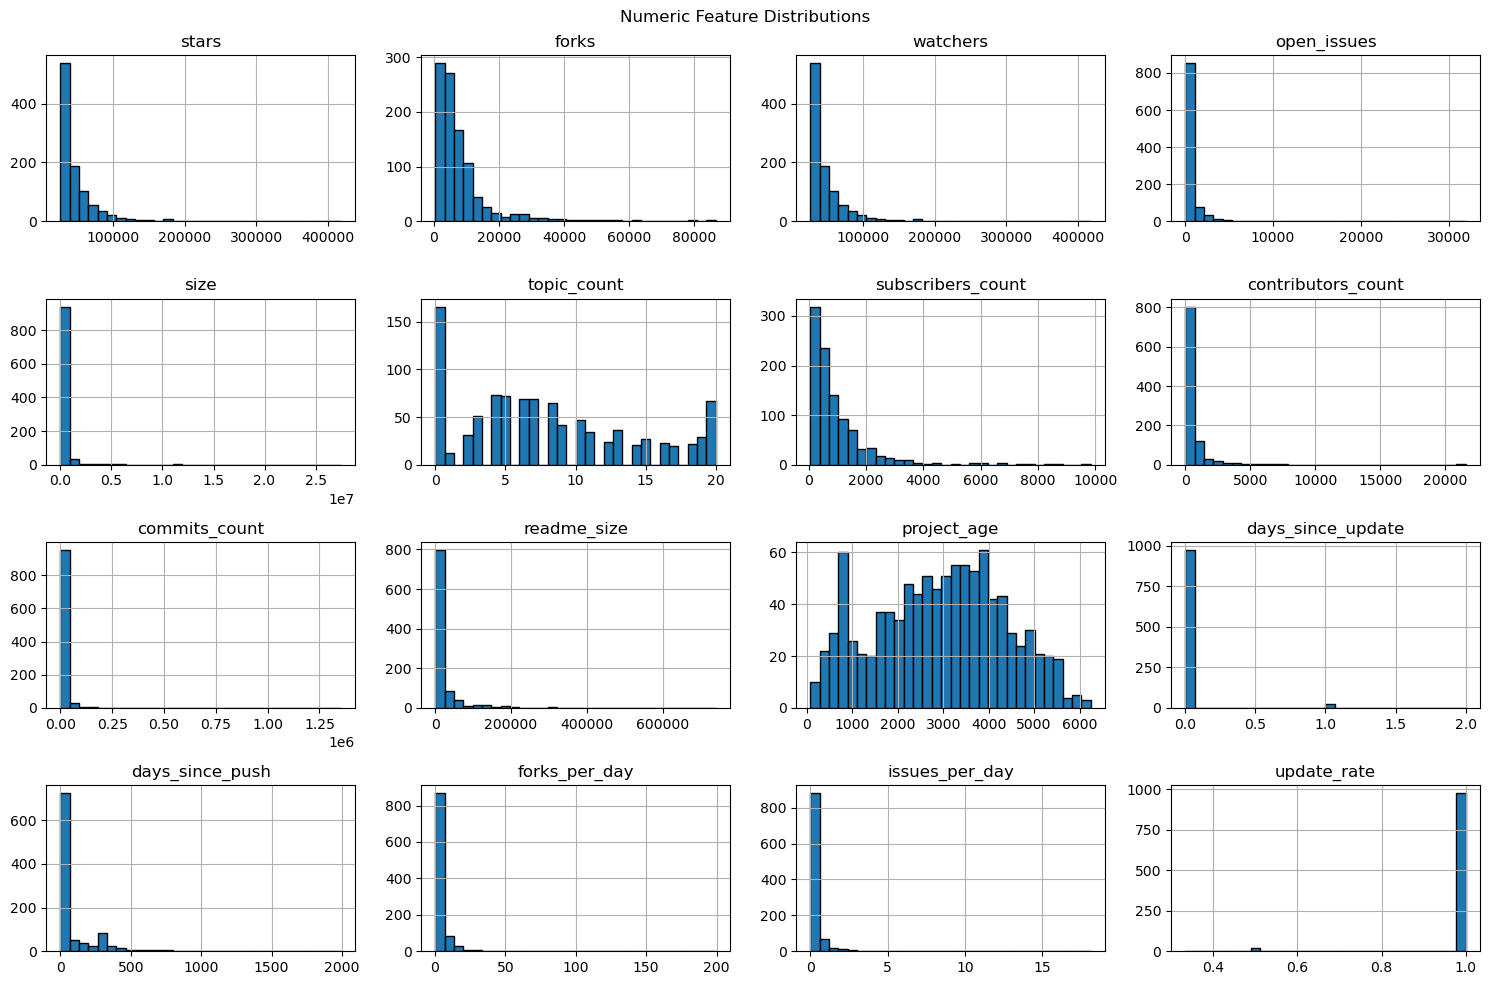

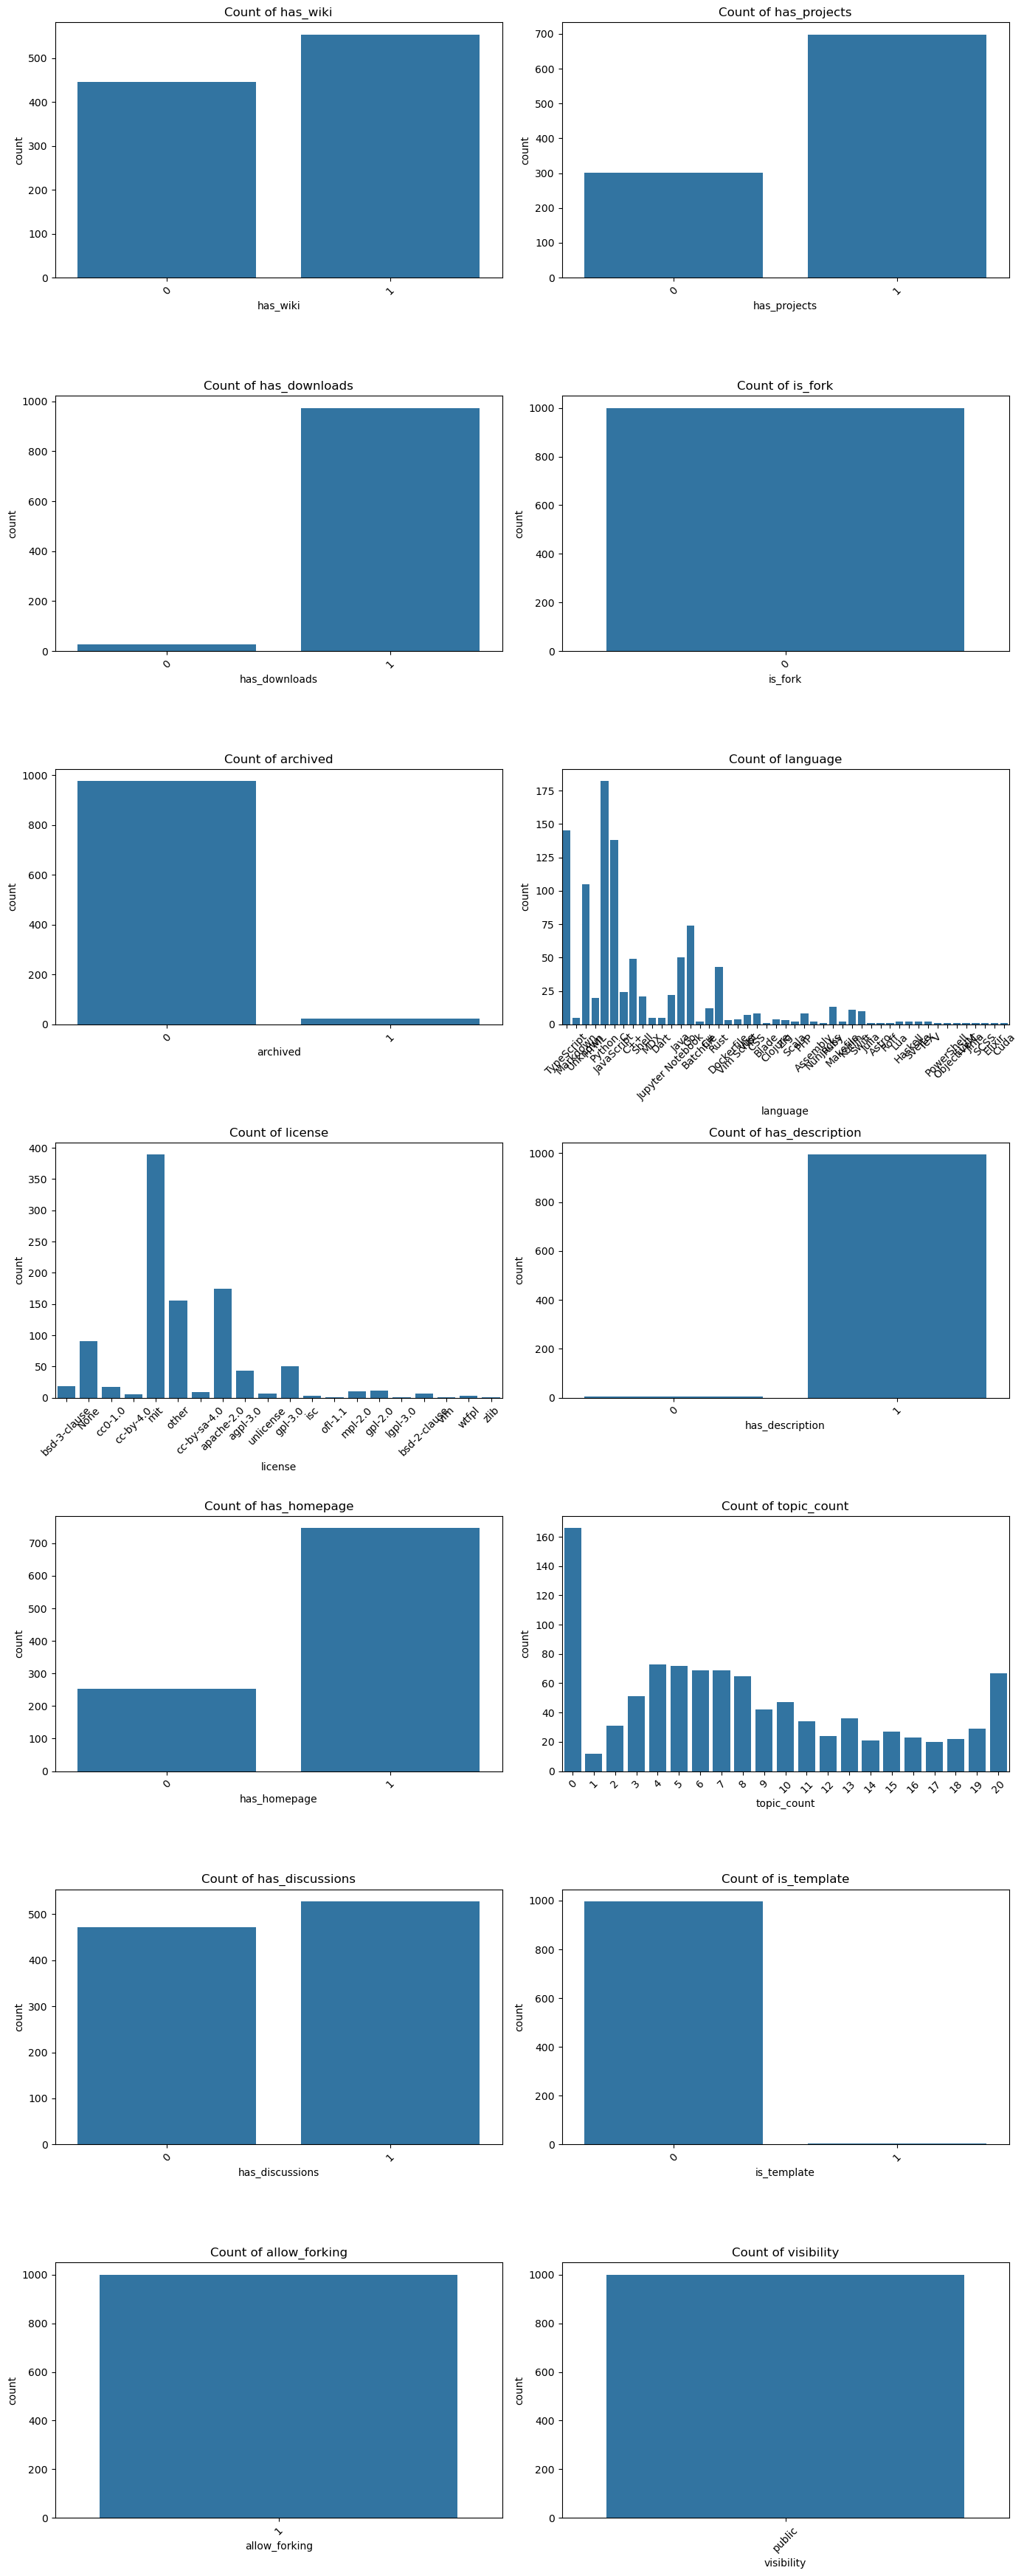

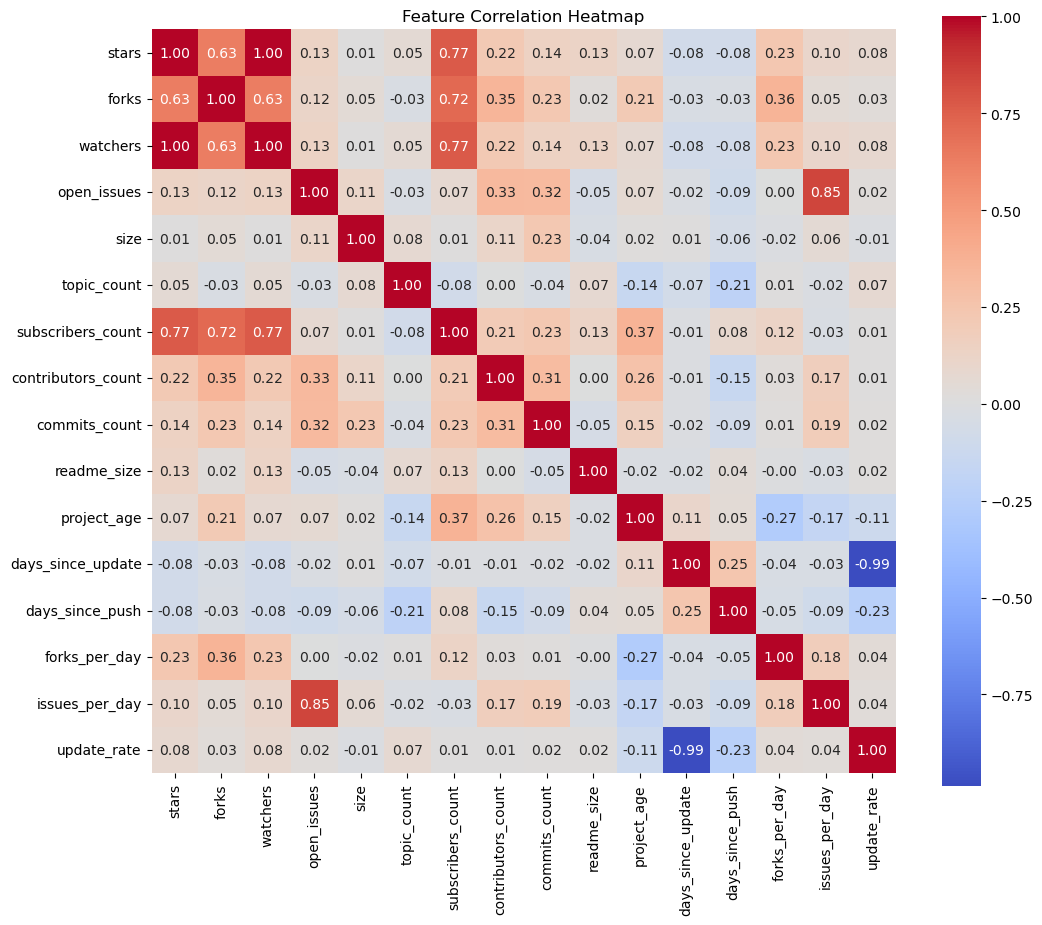

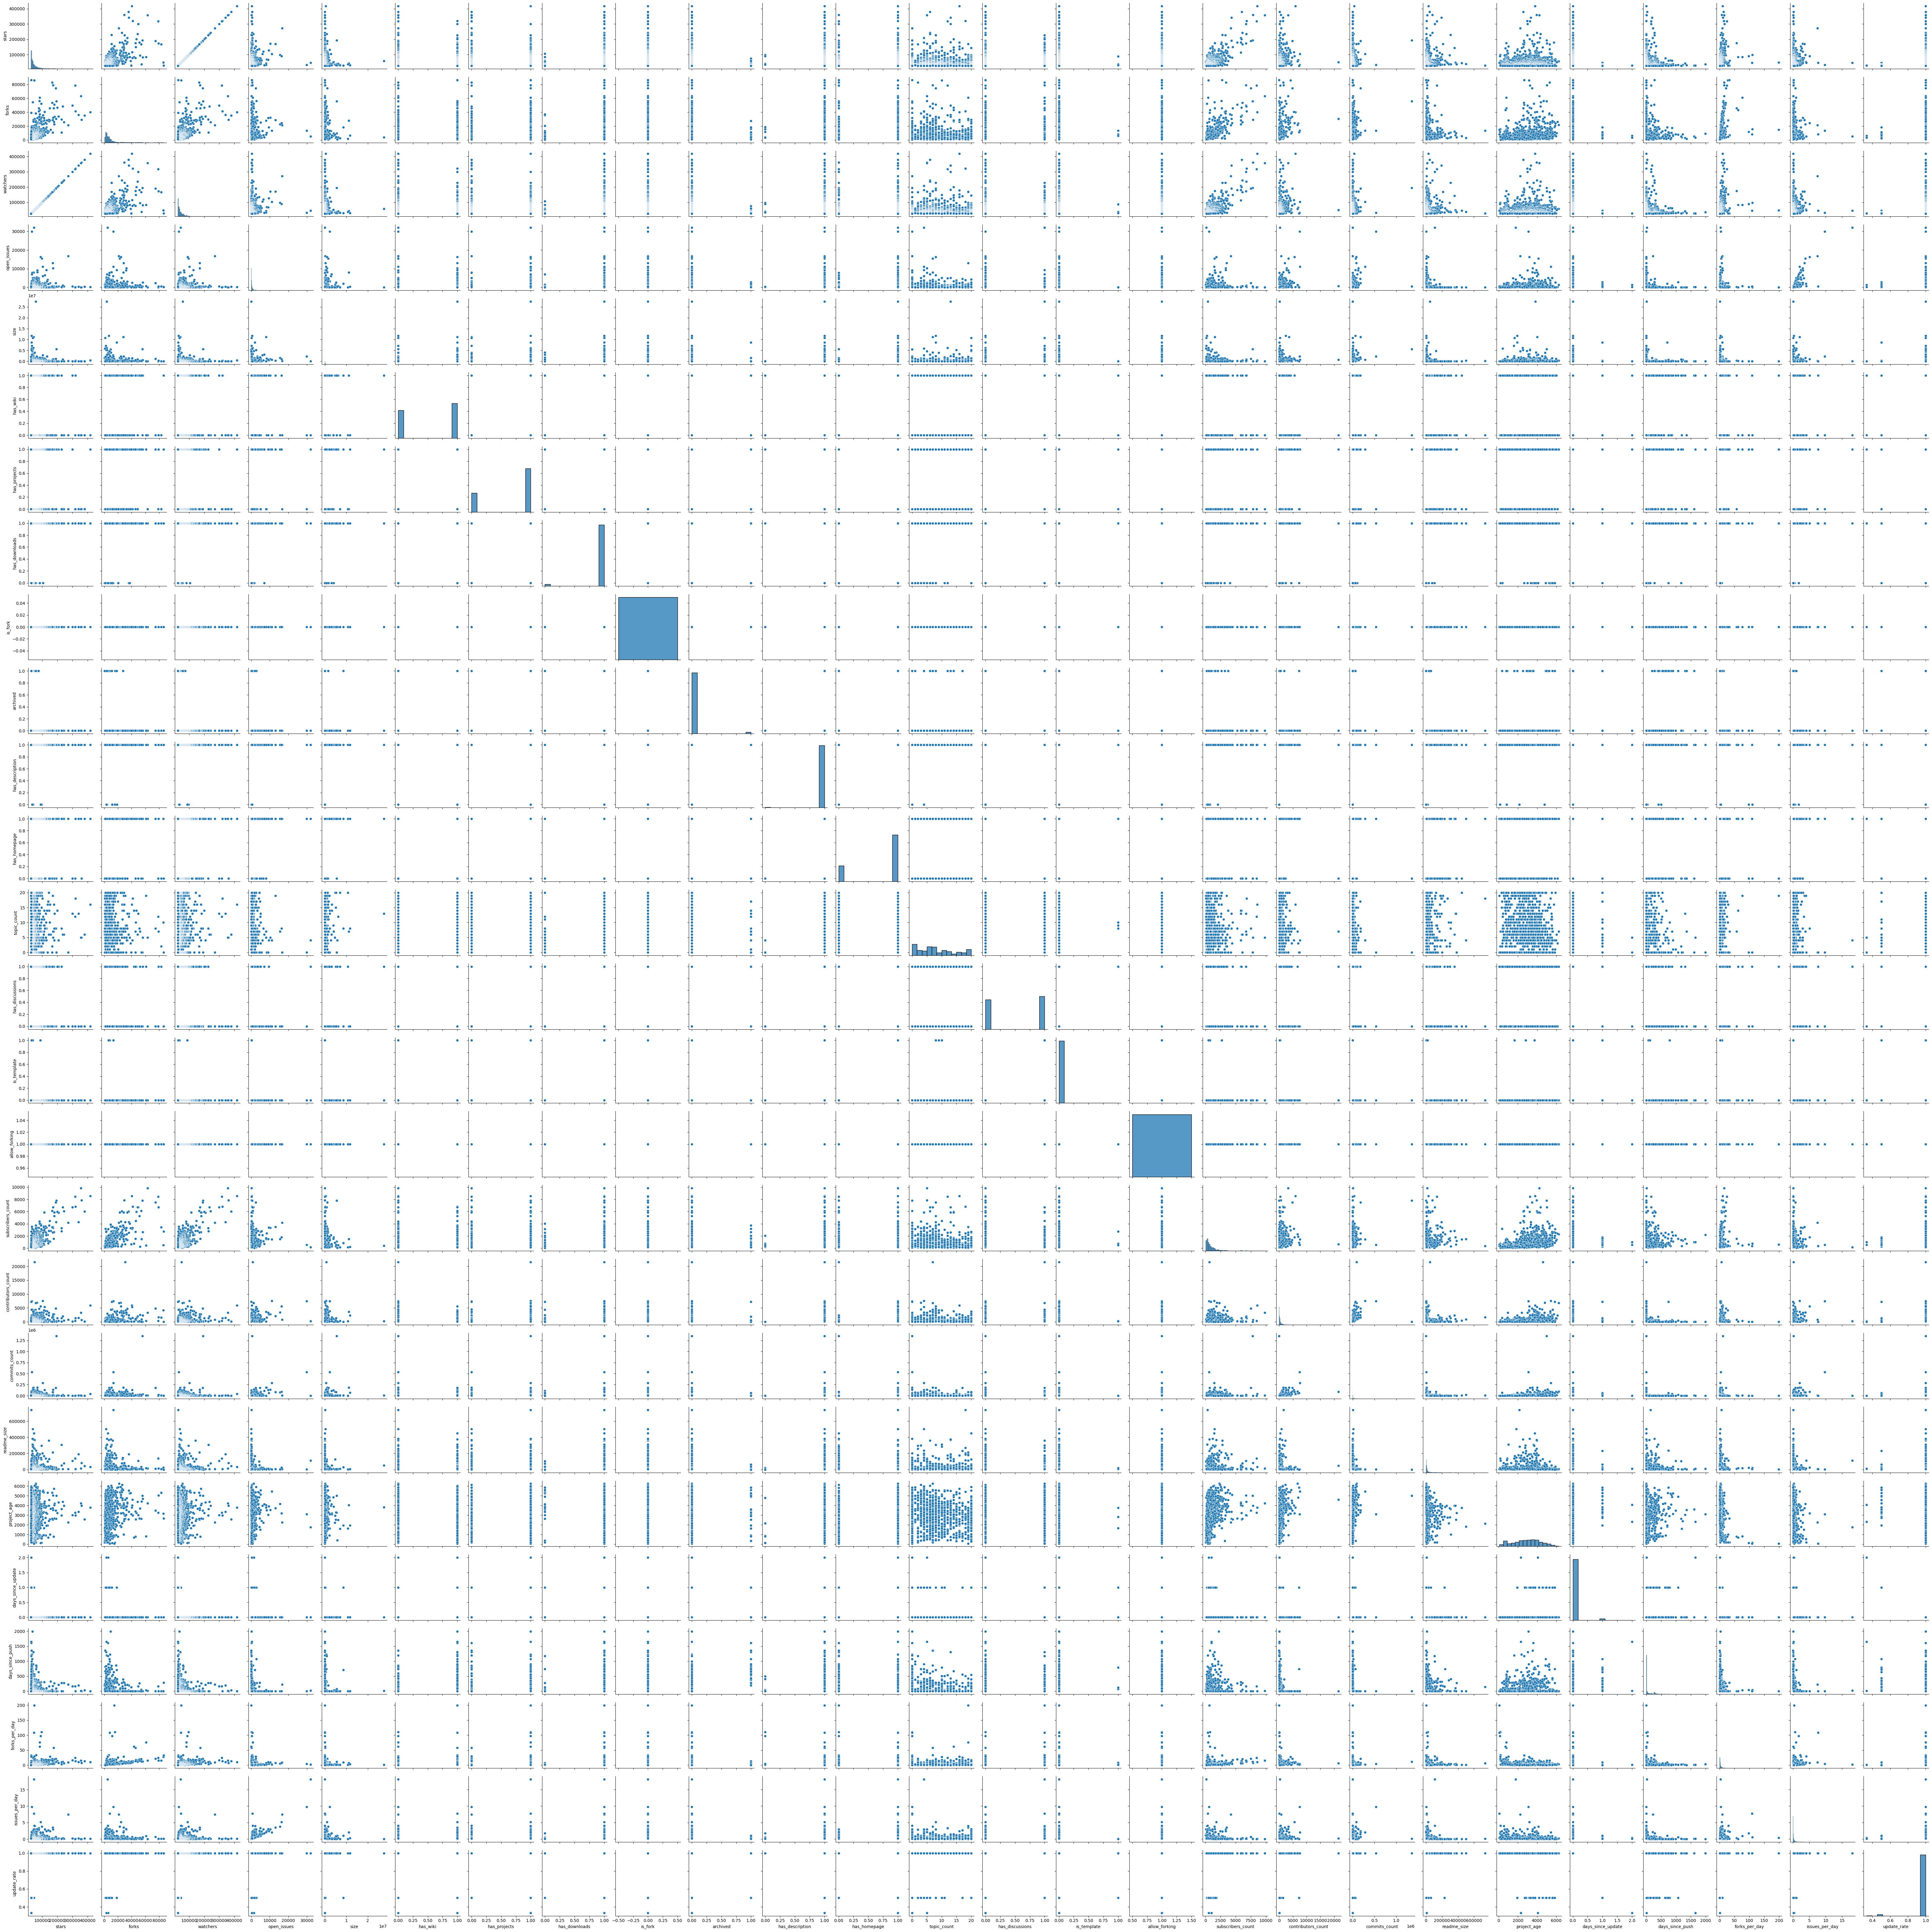

In [59]:
analyzer = GitHubRepoAnalyzer(df)

analyzer.plot_numeric_distributions() # view numeric distributions
analyzer.plot_categorical_counts() # view boolean/categorical feature distributions
analyzer.plot_correlation_heatmap() # view inter-feature correlation
analyzer.plot_pairplot() # view scatterplot matrix between first few variables

* Note that watchers is the same as stars!
* 'is_fork', 'allow_forking' and 'visibility' are all the same.

# Pipeline

In [39]:
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor, 
                             AdaBoostRegressor, ExtraTreesRegressor, BaggingRegressor)
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import joblib
import os


class GitHubRepoPreprocessor:
    """Custom preprocessing pipeline for GitHub repository metadata."""
    
    def __init__(self, reference_date=None):
        self.date = reference_date or datetime(2025, 5, 17)
        self.features = [
            'forks', 'open_issues',
       'size', 'has_wiki', 'has_projects', 'has_downloads', 
       'archived', 'language', 'license', 
       'has_description', 'has_homepage', 'topic_count',
       'has_discussions', 'is_template', 
       'subscribers_count', 'contributors_count', 'commits_count',
       'readme_size', 'project_age', 'days_since_push',
       'forks_per_day', 'issues_per_day'
        ] # delete 'watchers', 'is_fork', 'allow_forking', 'visibility', 'days_since_update' and 'update_rate'
        self.numeric_features = [
            'forks', 'open_issues',
            'size', 'topic_count', 'subscribers_count', 
            'contributors_count', 'commits_count', 'readme_size',
            'project_age', 'days_since_push',
            'forks_per_day', 'issues_per_day'
        ]
        self.categorical_features = ["language", "license"]
        self.column_transformer = None

    def transform(self, df):
        # Parse and normalize time-related features
        df["project_age"] = (self.date.date() - df["created_at"].dt.date).apply(lambda x: x.days)
        df["days_since_update"] = (self.date.date() - df["updated_at"].dt.date).apply(lambda x: x.days)
        df["days_since_push"] = (self.date.date() - df["pushed_at"].dt.date).apply(lambda x: x.days)

        # Handle missing values
        df["license"] = df["license"].fillna("None")
        df["language"] = df["language"].fillna("Unknown")

        # Derived rate-based features
        df["forks_per_day"] = df["forks"] / (df["project_age"] + 1)
        df["issues_per_day"] = df["open_issues"] / (df["project_age"] + 1)
        df["update_rate"] = 1 / (1 + df["days_since_update"])

        return df[self.features], df["stars"]

    def get_preprocessor(self):
        """Construct and return a fitted ColumnTransformer"""
        self.column_transformer = ColumnTransformer(
            transformers=[
                ("num", StandardScaler(), self.numeric_features),
                ("cat", OneHotEncoder(handle_unknown="ignore"), self.categorical_features)
            ]
        )
        return self.column_transformer


def train_and_evaluate_models(df, save_path="best_model_cv.pkl"):
    """Train multiple regressors and save the best performing one."""
    preprocessor = GitHubRepoPreprocessor()
    X, y = preprocessor.transform(df)
    
    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Preprocessing pipeline
    processor = preprocessor.get_preprocessor()

    # Candidate models
    models = {
        # Linear Models
        'Linear Regression': LinearRegression(),
        'Ridge (α=1.0)': Ridge(alpha=1.0),
        'Ridge (α=0.5)': Ridge(alpha=0.5),
        'Lasso (α=0.1)': Lasso(alpha=0.1),
        'ElasticNet (α=0.1)': ElasticNet(alpha=0.1, l1_ratio=0.5),
        
        # Tree-based Models
        'Decision Tree (max_depth=5)': DecisionTreeRegressor(max_depth=5, random_state=42),
        'Decision Tree (max_depth=10)': DecisionTreeRegressor(max_depth=10, random_state=42),
        
        # Ensemble Methods
        'Random Forest (n=100)': RandomForestRegressor(n_estimators=100, random_state=42),
        'Random Forest (n=200)': RandomForestRegressor(n_estimators=200, random_state=42),
        'Random Forest (n=200)': RandomForestRegressor(n_estimators=200, random_state=42),
        'Random Forest (n=300)': RandomForestRegressor(n_estimators=300, random_state=42),
        'Gradient Boosting (n=100)': GradientBoostingRegressor(n_estimators=100, random_state=42),
        'Gradient Boosting (n=200)': GradientBoostingRegressor(n_estimators=200, random_state=42),
        'AdaBoost': AdaBoostRegressor(random_state=42),
        'Extra Trees': ExtraTreesRegressor(random_state=42),
        'Bagging Regressor': BaggingRegressor(random_state=42),
        
        # SVM
        'SVR (linear)': SVR(kernel='linear'),
        'SVR (rbf)': SVR(kernel='rbf'),
        'SVR (poly)': SVR(kernel='poly'),
        
        # Neighbors
        'KNN (k=3)': KNeighborsRegressor(n_neighbors=3),
        'KNN (k=5)': KNeighborsRegressor(n_neighbors=5),
        'KNN (k=10)': KNeighborsRegressor(n_neighbors=10),
        
        # Neural Networks
        'MLP (1 layer)': MLPRegressor(hidden_layer_sizes=(128,), max_iter=1000, random_state=42),
        'MLP (2 layers)': MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=1000, random_state=42),
        'MLP (3 layers)': MLPRegressor(hidden_layer_sizes=(128, 64, 32), max_iter=1000, random_state=42),
        'MLP (4 layers)': MLPRegressor(hidden_layer_sizes=(128, 64, 32, 16), max_iter=1000, random_state=42),
        
        # Advanced Gradient Boosting
        'XGBoost': XGBRegressor(random_state=42),
        'LightGBM': LGBMRegressor(random_state=42)
    }

    results = []
    best_model = None
    best_score = -np.inf


    for name, model in models.items():
        try:
            pipeline = Pipeline([
                ("preprocessor", processor),
                ("regressor", model)
            ])

            
            pipeline.fit(X_train, y_train)
            y_pred = pipeline.predict(X_test)

            r2 = r2_score(y_test, y_pred)
            mse = mean_squared_error(y_test, y_pred)
            rmse = np.sqrt(mse)
            mae = mean_absolute_error(y_test, y_pred)

            # Store results
            model_params = str(model.get_params())
            results.append({
                'Model': name,
                'Parameters': model_params,
                'MSE': mse,
                'RMSE': rmse,
                'MAE': mae,
                'R2': r2
            })

            # Save the best model
            if r2 > best_score:
                best_score = r2
                best_model = Pipeline([
                ("preprocessor", processor),
                ("regressor", model)
            ])
                
            print(f"{name: <30} | R2: {r2:.4f} | RMSE: {rmse:.2f}")
            
        except Exception as e:
            print(f"Error with {name}: {str(e)}")
            continue

    # Convert results to DataFrame
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(by='R2', ascending=False)

    # Display all results
    print("\n=== All Model Results ===")
    print(results_df.to_string())

    if best_model:
        joblib.dump(best_model, save_path)
        print(f"\n Best model saved to: {os.path.abspath(save_path)}")
    
    return results_df

In [ ]:
# load data
df = pd.read_csv('github_repo_features_new.csv', parse_dates=["created_at", "updated_at", "pushed_at"])
results_df = train_and_evaluate_models(df, save_path="best_model.pkl")

Linear Regression              | R2: 0.4668 | RMSE: 20824.71
Ridge (α=1.0)                  | R2: 0.4851 | RMSE: 20464.44
Ridge (α=0.5)                  | R2: 0.4789 | RMSE: 20586.04
Lasso (α=0.1)                  | R2: 0.4661 | RMSE: 20836.94
ElasticNet (α=0.1)             | R2: 0.5292 | RMSE: 19567.06
Decision Tree (max_depth=5)    | R2: 0.3872 | RMSE: 22324.04
Decision Tree (max_depth=10)   | R2: 0.3738 | RMSE: 22567.55


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:639: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 13270888537.492523, tolerance: 151429513.5213338
  model = cd_fast.sparse_enet_coordinate_descent(


Random Forest (n=100)          | R2: 0.6113 | RMSE: 17778.99
Random Forest (n=200)          | R2: 0.6058 | RMSE: 17905.70
Random Forest (n=300)          | R2: 0.6030 | RMSE: 17969.19
Gradient Boosting (n=100)      | R2: 0.6042 | RMSE: 17942.28
Gradient Boosting (n=200)      | R2: 0.5984 | RMSE: 18072.51
AdaBoost                       | R2: 0.2773 | RMSE: 24244.49
Extra Trees                    | R2: 0.6628 | RMSE: 16560.26
Bagging Regressor              | R2: 0.5407 | RMSE: 19327.15
SVR (linear)                   | R2: -0.0755 | RMSE: 29575.08
SVR (rbf)                      | R2: -0.1141 | RMSE: 30101.20
SVR (poly)                     | R2: -0.1098 | RMSE: 30043.51
KNN (k=3)                      | R2: 0.5323 | RMSE: 19504.31
KNN (k=5)                      | R2: 0.4889 | RMSE: 20387.46
KNN (k=10)                     | R2: 0.5438 | RMSE: 19262.56


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLP (1 layer)                  | R2: -1.6254 | RMSE: 46208.36


...

MLP (2 layers)                 | R2: 0.4438 | RMSE: 21268.56


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLP (3 layers)                 | R2: 0.2843 | RMSE: 24126.14


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLP (4 layers)                 | R2: 0.1825 | RMSE: 25785.30
XGBoost                        | R2: 0.5094 | RMSE: 19975.84
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000099 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2709
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 27
[LightGBM] [Info] Start training from score 52325.408750
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM

In [28]:
import matplotlib.pyplot as plt
def visualize_results(results_df):
    plt.figure(figsize=(12, 8))
    
    # Sort by R2 score and plot
    results_df = results_df.sort_values(by='R2')
    bars = plt.barh(results_df['Model'], results_df['R2'], color='skyblue')
    
    # Add value labels
    for bar in bars:
        width = bar.get_width()
        plt.text(width, bar.get_y() + bar.get_height()/2, 
                f'{width:.3f}', 
                va='center', ha='left', fontsize=9)
    
    # Customize plot
    plt.xlabel('R2 Score', fontsize=12)
    plt.ylabel('Model', fontsize=12)
    plt.title('Model Performance Comparison', fontsize=14)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    
    # Save and show
    plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

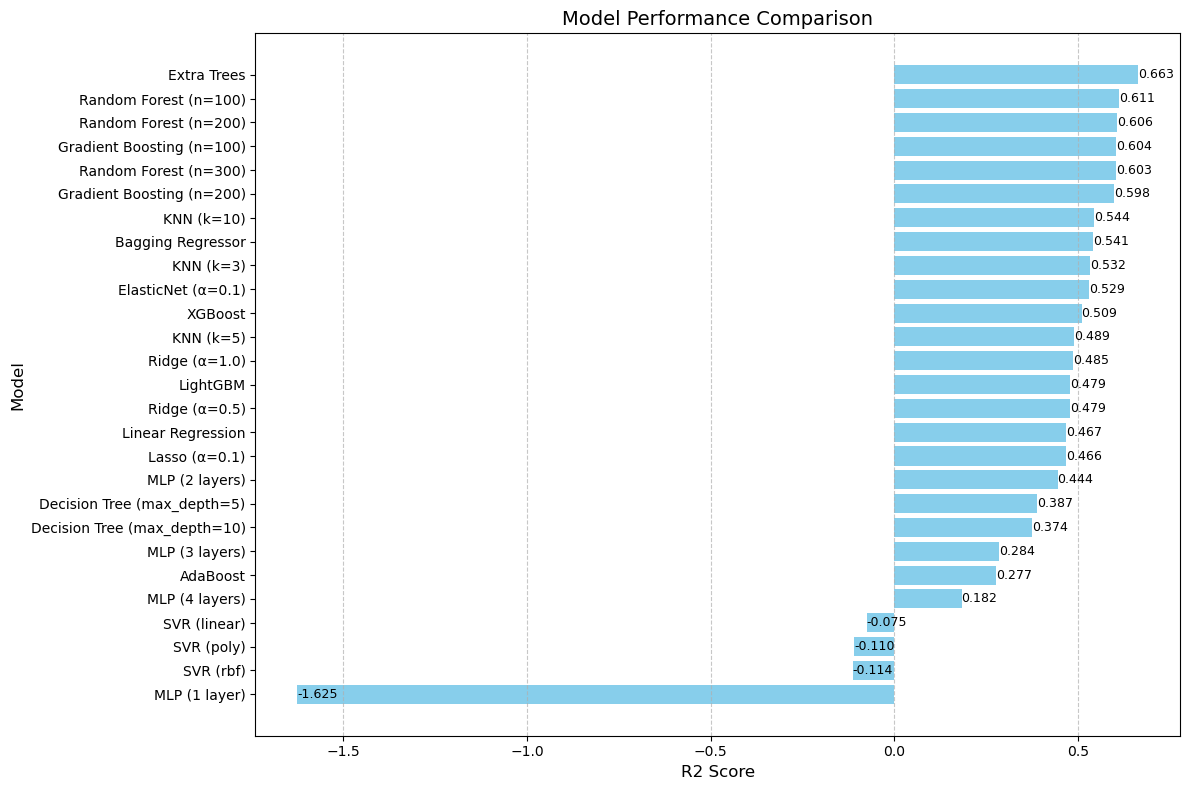

In [41]:
# Call the visualization function
visualize_results(results_df)

## Add Cross-validation

In [23]:
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor, 
                             AdaBoostRegressor, ExtraTreesRegressor, BaggingRegressor)
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import joblib
import os


class GitHubRepoPreprocessor:
    """Custom preprocessing pipeline for GitHub repository metadata."""
    
    def __init__(self, reference_date=None):
        self.date = reference_date or datetime(2025, 5, 17)
        self.features = [
            'forks', 'open_issues',
       'size', 'has_wiki', 'has_projects', 'has_downloads', 
       'archived', 'language', 'license', 
       'has_description', 'has_homepage', 'topic_count',
       'has_discussions', 'is_template', 
       'subscribers_count', 'contributors_count', 'commits_count',
       'readme_size', 'project_age', 'days_since_push',
       'forks_per_day', 'issues_per_day'
        ] # delete 'watchers', 'is_fork', 'allow_forking', 'visibility', 'days_since_update' and 'update_rate'
        self.numeric_features = [
            'forks', 'open_issues',
            'size', 'topic_count', 'subscribers_count', 
            'contributors_count', 'commits_count', 'readme_size',
            'project_age', 'days_since_push',
            'forks_per_day', 'issues_per_day'
        ]
        self.categorical_features = ["language", "license"]
        self.column_transformer = None

    def transform(self, df):
        # Parse and normalize time-related features
        df["project_age"] = (self.date.date() - df["created_at"].dt.date).apply(lambda x: x.days)
        df["days_since_update"] = (self.date.date() - df["updated_at"].dt.date).apply(lambda x: x.days)
        df["days_since_push"] = (self.date.date() - df["pushed_at"].dt.date).apply(lambda x: x.days)

        # Handle missing values
        df["license"] = df["license"].fillna("None")
        df["language"] = df["language"].fillna("Unknown")

        # Derived rate-based features
        df["forks_per_day"] = df["forks"] / (df["project_age"] + 1)
        df["issues_per_day"] = df["open_issues"] / (df["project_age"] + 1)
        df["update_rate"] = 1 / (1 + df["days_since_update"])
        
        return df[self.features], df["stars"]

    def get_preprocessor(self):
        """Construct and return a fitted ColumnTransformer"""
        self.column_transformer = ColumnTransformer(
            transformers=[
                ("num", StandardScaler(), self.numeric_features),
                ("cat", OneHotEncoder(handle_unknown="ignore"), self.categorical_features)
            ]
        )
        return self.column_transformer


def train_and_evaluate_models_cv(df, save_path="best_model_cv.pkl", n_splits=5):
    """Train multiple regressors and save the best performing one."""
    preprocessor = GitHubRepoPreprocessor()
    X, y = preprocessor.transform(df)
    
    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Preprocessing pipeline
    processor = preprocessor.get_preprocessor()

    # Candidate models
    models = {
        # Linear Models
        'Linear Regression': LinearRegression(),
        'Ridge (α=1.0)': Ridge(alpha=1.0),
        'Ridge (α=0.5)': Ridge(alpha=0.5),
        'Lasso (α=0.1)': Lasso(alpha=0.1),
        'ElasticNet (α=0.1)': ElasticNet(alpha=0.1, l1_ratio=0.5),
        
        # Tree-based Models
        'Decision Tree (max_depth=5)': DecisionTreeRegressor(max_depth=5, random_state=42),
        'Decision Tree (max_depth=10)': DecisionTreeRegressor(max_depth=10, random_state=42),
        
        # Ensemble Methods
        'Random Forest (n=50)': RandomForestRegressor(n_estimators=50, random_state=42),
        'Random Forest (n=100)': RandomForestRegressor(n_estimators=100, random_state=42),
        'Random Forest (n=200)': RandomForestRegressor(n_estimators=200, random_state=42),
        'Random Forest (n=300)': RandomForestRegressor(n_estimators=300, random_state=42),
        'Gradient Boosting (n=100)': GradientBoostingRegressor(n_estimators=100, random_state=42),
        'Gradient Boosting (n=200)': GradientBoostingRegressor(n_estimators=200, random_state=42),
        'AdaBoost': AdaBoostRegressor(random_state=42),
        'Extra Trees': ExtraTreesRegressor(random_state=42),
        'Bagging Regressor': BaggingRegressor(random_state=42),
        
        # SVM
        'SVR (linear)': SVR(kernel='linear'),
        'SVR (rbf)': SVR(kernel='rbf'),
        'SVR (poly)': SVR(kernel='poly'),
        
        # Neighbors
        'KNN (k=3)': KNeighborsRegressor(n_neighbors=3),
        'KNN (k=5)': KNeighborsRegressor(n_neighbors=5),
        'KNN (k=10)': KNeighborsRegressor(n_neighbors=10),
        
        # Neural Networks
        'MLP (1 layer)': MLPRegressor(hidden_layer_sizes=(128,), max_iter=1000, random_state=42),
        'MLP (2 layers)': MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=1000, random_state=42),
        'MLP (3 layers)': MLPRegressor(hidden_layer_sizes=(128, 64, 32), max_iter=1000, random_state=42),
        'MLP (4 layers)': MLPRegressor(hidden_layer_sizes=(128, 64, 32, 16), max_iter=1000, random_state=42),
        
        # Advanced Gradient Boosting
        'XGBoost': XGBRegressor(random_state=42),
        'LightGBM': LGBMRegressor(random_state=42)
    }

    results = []
    best_cv_score = -np.inf
    best_model = None
    best_pipeline = None
    test_r2_best = -np.inf


    for name, model in models.items():
        try:
            pipeline = Pipeline([
                ("preprocessor", processor),
                ("regressor", model)
            ])

            # Cross-validation on training set
            cv = KFold(n_splits=n_splits, shuffle=True, random_state=42)
            cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='r2')

            cv_mean = np.mean(cv_scores)
            cv_std = np.std(cv_scores)

            # Select best model based on CV mean
            if cv_mean > best_cv_score:
                best_cv_score = cv_mean
                best_model = model

            results.append({
                'Model': name,
                'CV R2 Mean': cv_mean,
                'CV R2 Std': cv_std,
            })

            print(f"{name:<25} | CV R2: {cv_mean:.4f} ± {cv_std:.4f}")
            
        except Exception as e:
            print(f"Error with {name}: {str(e)}")
            continue

    if best_model is not None:
        final_pipeline = Pipeline([
            ("preprocessor", processor),
            ("regressor", best_model)
        ])
        final_pipeline.fit(X_train, y_train)
        y_test_pred = final_pipeline.predict(X_test)
        test_r2 = r2_score(y_test, y_test_pred)

        print(f"\n=== Best Model: {best_model.__class__.__name__} ===")
        print(f"Test R2 Score: {test_r2:.4f}")

        joblib.dump(final_pipeline, save_path)
        print(f"Best model saved to: {os.path.abspath(save_path)}")

        # Save the best model
        test_r2_best = test_r2
        best_pipeline = final_pipeline

    # Return summary
    results_df = pd.DataFrame(results).sort_values(by='CV R2 Mean', ascending=False)
    return results_df, best_pipeline, test_r2_best


In [ ]:
# load data
df = pd.read_csv('github_repo_features_new.csv', parse_dates=["created_at", "updated_at", "pushed_at"])
results_df_cv, best_pipeline, test_r2_best = train_and_evaluate_models_cv(df, save_path="best_model_cv.pkl")

Linear Regression         | CV R2: 0.5631 ± 0.2288
Ridge (α=1.0)             | CV R2: 0.5885 ± 0.2073
Ridge (α=0.5)             | CV R2: 0.5809 ± 0.2147


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:639: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 22157562031.933624, tolerance: 116177047.82255821
  model = cd_fast.sparse_enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:639: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 43679582081.830444, tolerance: 131395582.11836006
  model = cd_fast.sparse_enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:639: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 9375408459.938812, tolerance: 112683003.04939249
  model = cd_fast.sparse_enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_des

Lasso (α=0.1)             | CV R2: 0.5634 ± 0.2295
ElasticNet (α=0.1)        | CV R2: 0.6169 ± 0.1730
Decision Tree (max_depth=5) | CV R2: 0.4659 ± 0.1868
Decision Tree (max_depth=10) | CV R2: 0.3238 ± 0.2072
Random Forest (n=50)      | CV R2: 0.6457 ± 0.1678
Random Forest (n=100)     | CV R2: 0.6467 ± 0.1701
Random Forest (n=200)     | CV R2: 0.6572 ± 0.1595
Random Forest (n=300)     | CV R2: 0.6538 ± 0.1620
Gradient Boosting (n=100) | CV R2: 0.6772 ± 0.1398
Gradient Boosting (n=200) | CV R2: 0.6827 ± 0.1450
AdaBoost                  | CV R2: 0.5197 ± 0.1971
Extra Trees               | CV R2: 0.6707 ± 0.1438
Bagging Regressor         | CV R2: 0.6184 ± 0.1589
SVR (linear)              | CV R2: -0.0883 ± 0.0231
SVR (rbf)                 | CV R2: -0.1119 ± 0.0259
SVR (poly)                | CV R2: -0.1080 ± 0.0270
KNN (k=3)                 | CV R2: 0.4983 ± 0.1484
KNN (k=5)                 | CV R2: 0.5506 ± 0.0977
KNN (k=10)                | CV R2: 0.5635 ± 0.1004


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_netwo

MLP (1 layer)             | CV R2: -1.0040 ± 0.4620


...

MLP (2 layers)            | CV R2: 0.6318 ± 0.1882


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_netwo

MLP (3 layers)            | CV R2: 0.6399 ± 0.1910


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_netwo

MLP (4 layers)            | CV R2: 0.6029 ± 0.2061
XGBoost                   | CV R2: 0.5818 ± 0.2079
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000160 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2279
[LightGBM] [Info] Number of data points in the train set: 640, number of used features: 26
[LightGBM] [Info] Start training from score 51904.304688
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furth

In [14]:
import matplotlib.pyplot as plt
def visualize_results_cv(results_df):
    plt.figure(figsize=(12, 8))
    
    # Sort by R2 score and plot
    results_df = results_df.sort_values(by='CV R2 Mean')

    bars = plt.barh(results_df['Model'], results_df['CV R2 Mean'], color='skyblue')
    
    # Add value labels
    for bar in bars:
        width = bar.get_width()
        plt.text(width, bar.get_y() + bar.get_height()/2, 
                f'{width:.3f}', 
                va='center', ha='left', fontsize=9)
    
    # Customize plot
    plt.xlabel('R2 Score', fontsize=12)
    plt.ylabel('Model', fontsize=12)
    plt.title('Model Performance Comparison', fontsize=14)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    
    # Save and show
    plt.savefig('model_comparison_cv.png', dpi=300, bbox_inches='tight')
    plt.show()

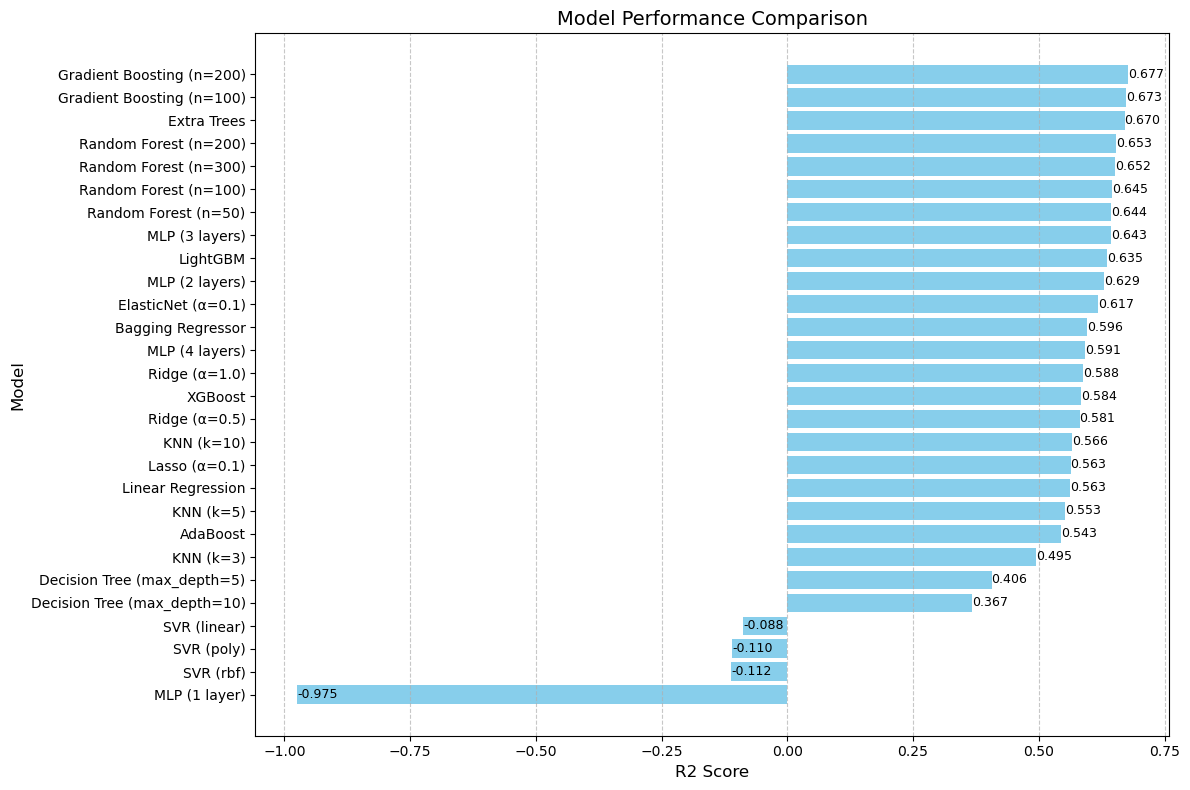

In [ ]:
# Call the visualization function
# With all features
visualize_results_cv(results_df_cv)

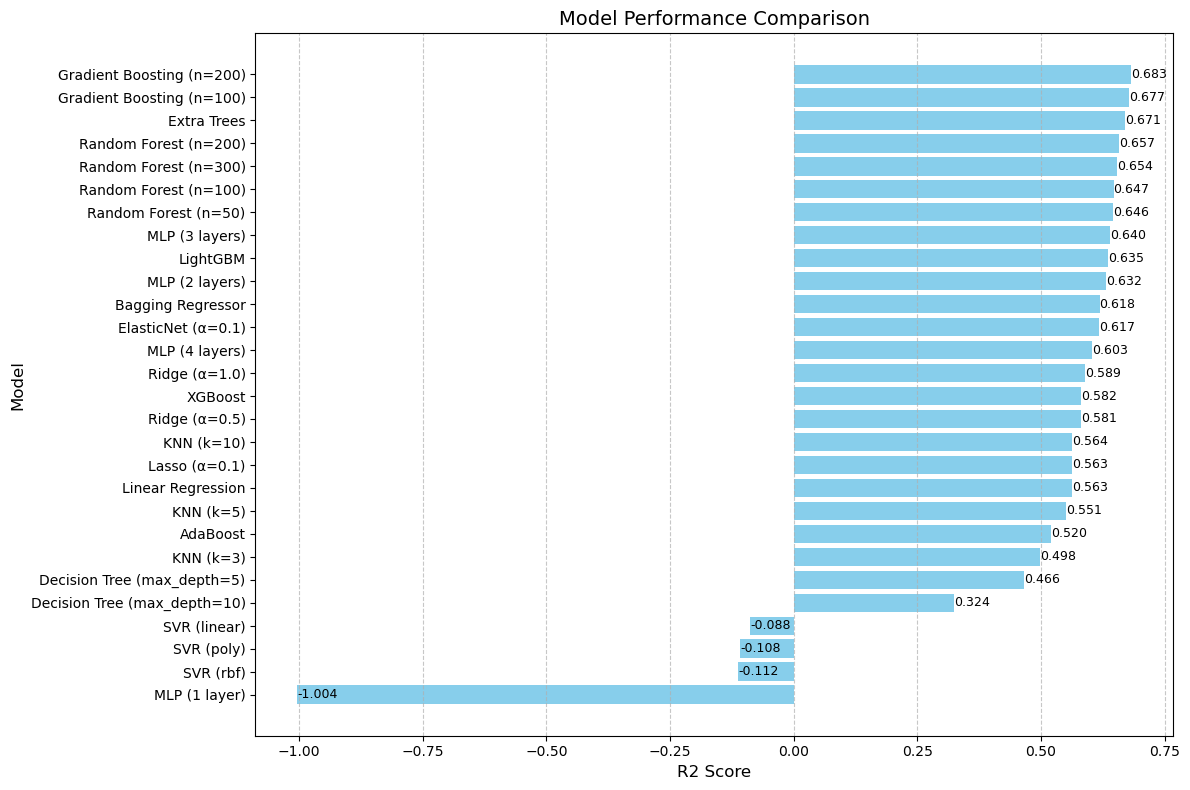

In [66]:
# Delete 'days_since_update', 'update_rate'
visualize_results_cv(results_df_cv)

## Experiments - feature selection

In [12]:
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor, 
                             AdaBoostRegressor, ExtraTreesRegressor, BaggingRegressor)
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import joblib
import os


class GitHubRepoPreprocessor:
    """Custom preprocessing pipeline for GitHub repository metadata."""
    
    def __init__(self, reference_date=None, exclude_features=None):
        self.date = reference_date or datetime(2025, 5, 17)
        self.exclude_features = exclude_features or []
        all_features = [
            'forks', 'open_issues',
       'size', 'has_wiki', 'has_projects', 'has_downloads', 
       'archived', 'language', 'license', 
       'has_description', 'has_homepage', 'topic_count',
       'has_discussions', 'is_template', 
       'subscribers_count', 'contributors_count', 'commits_count',
       'readme_size', 'project_age', 'days_since_update', 'days_since_push',
       'forks_per_day', 'issues_per_day', 'update_rate'
        ] # delete 'watchers', 'is_fork', 'allow_forking' and 'visibility'
        
        all_numeric = [
            'forks', 'open_issues',
            'size', 'topic_count', 'subscribers_count', 
            'contributors_count', 'commits_count', 'readme_size',
            'project_age', 'days_since_update', 'days_since_push',
            'forks_per_day', 'issues_per_day', 'update_rate'
        ]
        self.features = [f for f in all_features if f not in self.exclude_features]
        self.numeric_features = [f for f in all_numeric if f not in self.exclude_features]
        self.categorical_features = ["language", "license"]
        self.column_transformer = None

    def transform(self, df):
        # Parse and normalize time-related features
        df["project_age"] = (self.date.date() - df["created_at"].dt.date).apply(lambda x: x.days)
        df["days_since_update"] = (self.date.date() - df["updated_at"].dt.date).apply(lambda x: x.days)
        df["days_since_push"] = (self.date.date() - df["pushed_at"].dt.date).apply(lambda x: x.days)

        # Handle missing values
        df["license"] = df["license"].fillna("None")
        df["language"] = df["language"].fillna("Unknown")

        # Derived rate-based features
        df["forks_per_day"] = df["forks"] / (df["project_age"] + 1)
        df["issues_per_day"] = df["open_issues"] / (df["project_age"] + 1)
        df["update_rate"] = 1 / (1 + df["days_since_update"])

        
        return df[self.features], df["stars"]

    def get_preprocessor(self):
        """Construct and return a fitted ColumnTransformer"""
        self.column_transformer = ColumnTransformer(
            transformers=[
                ("num", StandardScaler(), self.numeric_features),
                ("cat", OneHotEncoder(handle_unknown="ignore"), self.categorical_features)
            ]
        )
        return self.column_transformer


def train_and_evaluate_models_cv(df, save_path="best_model_cv.pkl", n_splits=5, exclude_features=None):
    """Train multiple regressors and save the best performing one."""
    preprocessor = GitHubRepoPreprocessor(exclude_features=exclude_features)
    X, y = preprocessor.transform(df)
    
    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Preprocessing pipeline
    processor = preprocessor.get_preprocessor()

    # Candidate models
    models = {
        # Linear Models
        'Linear Regression': LinearRegression(),
        'Ridge (α=1.0)': Ridge(alpha=1.0),
        'Ridge (α=0.5)': Ridge(alpha=0.5),
        'Lasso (α=0.1)': Lasso(alpha=0.1),
        'ElasticNet (α=0.1)': ElasticNet(alpha=0.1, l1_ratio=0.5),
        
        # Tree-based Models
        'Decision Tree (max_depth=5)': DecisionTreeRegressor(max_depth=5, random_state=42),
        'Decision Tree (max_depth=10)': DecisionTreeRegressor(max_depth=10, random_state=42),
        
        # Ensemble Methods
        'Random Forest (n=50)': RandomForestRegressor(n_estimators=50, random_state=42),
        'Random Forest (n=100)': RandomForestRegressor(n_estimators=100, random_state=42),
        'Random Forest (n=200)': RandomForestRegressor(n_estimators=200, random_state=42),
        'Random Forest (n=300)': RandomForestRegressor(n_estimators=300, random_state=42),
        'Gradient Boosting (n=100)': GradientBoostingRegressor(n_estimators=100, random_state=42),
        'Gradient Boosting (n=200)': GradientBoostingRegressor(n_estimators=200, random_state=42),
        'AdaBoost': AdaBoostRegressor(random_state=42),
        'Extra Trees': ExtraTreesRegressor(random_state=42),
        'Bagging Regressor': BaggingRegressor(random_state=42),
        
        # SVM
        'SVR (linear)': SVR(kernel='linear'),
        'SVR (rbf)': SVR(kernel='rbf'),
        'SVR (poly)': SVR(kernel='poly'),
        
        # Neighbors
        'KNN (k=3)': KNeighborsRegressor(n_neighbors=3),
        'KNN (k=5)': KNeighborsRegressor(n_neighbors=5),
        'KNN (k=10)': KNeighborsRegressor(n_neighbors=10),
        
        # Neural Networks
        'MLP (1 layer)': MLPRegressor(hidden_layer_sizes=(128,), max_iter=1000, random_state=42),
        'MLP (2 layers)': MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=1000, random_state=42),
        'MLP (3 layers)': MLPRegressor(hidden_layer_sizes=(128, 64, 32), max_iter=1000, random_state=42),
        'MLP (4 layers)': MLPRegressor(hidden_layer_sizes=(128, 64, 32, 16), max_iter=1000, random_state=42),
        
        # Advanced Gradient Boosting
        'XGBoost': XGBRegressor(random_state=42),
        'LightGBM': LGBMRegressor(random_state=42)
    }

    results = []
    best_cv_score = -np.inf
    best_model = None
    best_pipeline = None
    test_r2_best = -np.inf


    for name, model in models.items():
        try:
            pipeline = Pipeline([
                ("preprocessor", processor),
                ("regressor", model)
            ])

            # Cross-validation on training set
            cv = KFold(n_splits=n_splits, shuffle=True, random_state=42)
            cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='r2')

            cv_mean = np.mean(cv_scores)
            cv_std = np.std(cv_scores)

            # Select best model based on CV mean
            if cv_mean > best_cv_score:
                best_cv_score = cv_mean
                best_model = model

            results.append({
                'Model': name,
                'CV R2 Mean': cv_mean,
                'CV R2 Std': cv_std,
            })

            print(f"{name:<25} | CV R2: {cv_mean:.4f} ± {cv_std:.4f}")
            
        except Exception as e:
            print(f"Error with {name}: {str(e)}")
            continue

    if best_model is not None:
        final_pipeline = Pipeline([
            ("preprocessor", processor),
            ("regressor", best_model)
        ])
        final_pipeline.fit(X_train, y_train)
        y_test_pred = final_pipeline.predict(X_test)
        test_r2 = r2_score(y_test, y_test_pred)

        print(f"\n=== Best Model: {best_model.__class__.__name__} ===")
        print(f"Test R2 Score: {test_r2:.4f}")

        joblib.dump(final_pipeline, save_path)
        print(f"Best model saved to: {os.path.abspath(save_path)}")

        # Save the best model
        test_r2_best = test_r2
        best_pipeline = final_pipeline

    # Return summary
    results_df = pd.DataFrame(results).sort_values(by='CV R2 Mean', ascending=False)
    return results_df, best_pipeline, test_r2_best


Linear Regression         | CV R2: 0.5628 ± 0.2288
Ridge (α=1.0)             | CV R2: 0.5883 ± 0.2071
Ridge (α=0.5)             | CV R2: 0.5809 ± 0.2147


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:639: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 22148349883.358063, tolerance: 116177047.82255821
  model = cd_fast.sparse_enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:639: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 43682886368.16281, tolerance: 131395582.11836006
  model = cd_fast.sparse_enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:639: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 9375039432.955292, tolerance: 112683003.04939249
  model = cd_fast.sparse_enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_desc

Lasso (α=0.1)             | CV R2: 0.5630 ± 0.2295
ElasticNet (α=0.1)        | CV R2: 0.6169 ± 0.1725
Decision Tree (max_depth=5) | CV R2: 0.4059 ± 0.2220
Decision Tree (max_depth=10) | CV R2: 0.3673 ± 0.2921
Random Forest (n=50)      | CV R2: 0.6439 ± 0.1656
Random Forest (n=100)     | CV R2: 0.6450 ± 0.1707
Random Forest (n=200)     | CV R2: 0.6530 ± 0.1646
Random Forest (n=300)     | CV R2: 0.6520 ± 0.1665
Gradient Boosting (n=100) | CV R2: 0.6729 ± 0.1427
Gradient Boosting (n=200) | CV R2: 0.6770 ± 0.1476
AdaBoost                  | CV R2: 0.5433 ± 0.1694
Extra Trees               | CV R2: 0.6704 ± 0.1442
Bagging Regressor         | CV R2: 0.5963 ± 0.1870
SVR (linear)              | CV R2: -0.0881 ± 0.0231
SVR (rbf)                 | CV R2: -0.1119 ± 0.0260
SVR (poly)                | CV R2: -0.1097 ± 0.0259
KNN (k=3)                 | CV R2: 0.4946 ± 0.1615
KNN (k=5)                 | CV R2: 0.5530 ± 0.1005
KNN (k=10)                | CV R2: 0.5665 ± 0.1017


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_netwo

MLP (1 layer)             | CV R2: -0.9752 ± 0.4445


...

MLP (2 layers)            | CV R2: 0.6289 ± 0.1949


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_netwo

MLP (3 layers)            | CV R2: 0.6428 ± 0.1918


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_netwo

MLP (4 layers)            | CV R2: 0.5913 ± 0.2169
XGBoost                   | CV R2: 0.5835 ± 0.2023
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000528 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2279
[LightGBM] [Info] Number of data points in the train set: 640, number of used features: 26
[LightGBM] [Info] Start training from score 51904.304688
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits w

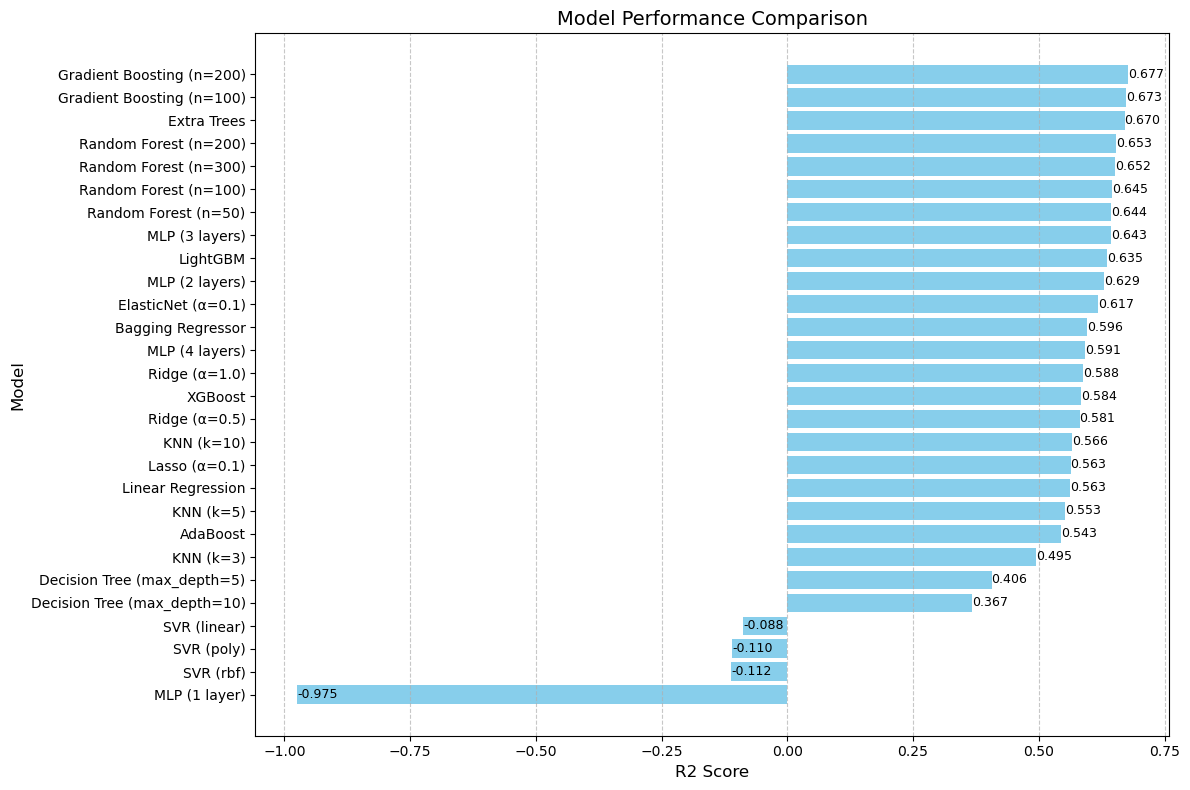

In [ ]:
# With all features
df = pd.read_csv('github_repo_features_new.csv', parse_dates=["created_at", "updated_at", "pushed_at"])
results_df_cv, best_pipeline, test_r2_best = train_and_evaluate_models_cv(df, save_path="best_model_cv.pkl", exclude_features=[])
visualize_results_cv(results_df_cv)

In [ ]:
# Delete 'days_since_update', 'update_rate'
df = pd.read_csv('github_repo_features_new.csv', parse_dates=["created_at", "updated_at", "pushed_at"])
results_df_cv, best_pipeline, test_r2_best = train_and_evaluate_models_cv(df, save_path="best_model_cv.pkl", exclude_features=['days_since_update', 'update_rate'])


Linear Regression         | CV R2: 0.5631 ± 0.2288
Ridge (α=1.0)             | CV R2: 0.5885 ± 0.2073
Ridge (α=0.5)             | CV R2: 0.5809 ± 0.2147


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:639: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 22157562031.933624, tolerance: 116177047.82255821
  model = cd_fast.sparse_enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:639: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 43679582081.830444, tolerance: 131395582.11836006
  model = cd_fast.sparse_enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:639: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 9375408459.938812, tolerance: 112683003.04939249
  model = cd_fast.sparse_enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_des

Lasso (α=0.1)             | CV R2: 0.5634 ± 0.2295
ElasticNet (α=0.1)        | CV R2: 0.6169 ± 0.1730
Decision Tree (max_depth=5) | CV R2: 0.4659 ± 0.1868
Decision Tree (max_depth=10) | CV R2: 0.3238 ± 0.2072
Random Forest (n=50)      | CV R2: 0.6457 ± 0.1678
Random Forest (n=100)     | CV R2: 0.6467 ± 0.1701
Random Forest (n=200)     | CV R2: 0.6572 ± 0.1595
Random Forest (n=300)     | CV R2: 0.6538 ± 0.1620
Gradient Boosting (n=100) | CV R2: 0.6772 ± 0.1398
Gradient Boosting (n=200) | CV R2: 0.6827 ± 0.1450
AdaBoost                  | CV R2: 0.5197 ± 0.1971
Extra Trees               | CV R2: 0.6707 ± 0.1438
Bagging Regressor         | CV R2: 0.6184 ± 0.1589
SVR (linear)              | CV R2: -0.0883 ± 0.0231
SVR (rbf)                 | CV R2: -0.1119 ± 0.0259
SVR (poly)                | CV R2: -0.1080 ± 0.0270
KNN (k=3)                 | CV R2: 0.4983 ± 0.1484
KNN (k=5)                 | CV R2: 0.5506 ± 0.0977
KNN (k=10)                | CV R2: 0.5635 ± 0.1004


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_netwo

MLP (1 layer)             | CV R2: -1.0040 ± 0.4620


...

MLP (2 layers)            | CV R2: 0.6318 ± 0.1882


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_netwo

MLP (3 layers)            | CV R2: 0.6399 ± 0.1910


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_netwo

MLP (4 layers)            | CV R2: 0.6029 ± 0.2061
XGBoost                   | CV R2: 0.5818 ± 0.2079
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000241 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2279
[LightGBM] [Info] Number of data points in the train set: 640, number of used features: 26
[LightGBM] [Info] Start training from score 51904.304688
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furth

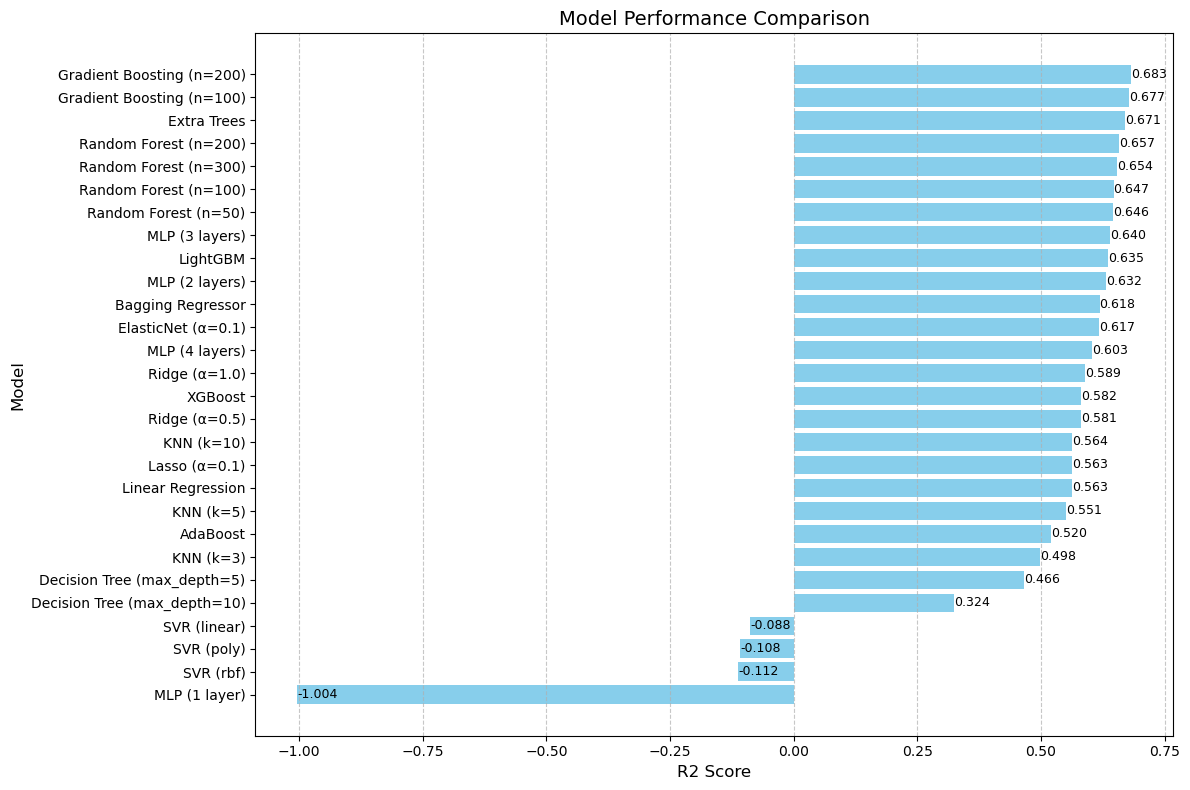

In [15]:
visualize_results_cv(results_df_cv)

Linear Regression         | CV R2: 0.5631 ± 0.2288
Ridge (α=1.0)             | CV R2: 0.5885 ± 0.2073
Ridge (α=0.5)             | CV R2: 0.5809 ± 0.2147


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:639: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 22157562031.933624, tolerance: 116177047.82255821
  model = cd_fast.sparse_enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:639: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 43679582081.830444, tolerance: 131395582.11836006
  model = cd_fast.sparse_enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:639: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 9375408459.938812, tolerance: 112683003.04939249
  model = cd_fast.sparse_enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_des

Lasso (α=0.1)             | CV R2: 0.5634 ± 0.2295
ElasticNet (α=0.1)        | CV R2: 0.6169 ± 0.1730
Decision Tree (max_depth=5) | CV R2: 0.4659 ± 0.1868
Decision Tree (max_depth=10) | CV R2: 0.3238 ± 0.2072
Random Forest (n=50)      | CV R2: 0.6457 ± 0.1678
Random Forest (n=100)     | CV R2: 0.6467 ± 0.1701
Random Forest (n=200)     | CV R2: 0.6572 ± 0.1595
Random Forest (n=300)     | CV R2: 0.6538 ± 0.1620
Gradient Boosting (n=100) | CV R2: 0.6772 ± 0.1398
Gradient Boosting (n=200) | CV R2: 0.6827 ± 0.1450
AdaBoost                  | CV R2: 0.5197 ± 0.1971
Extra Trees               | CV R2: 0.6707 ± 0.1438
Bagging Regressor         | CV R2: 0.6184 ± 0.1589
SVR (linear)              | CV R2: -0.0883 ± 0.0231
SVR (rbf)                 | CV R2: -0.1119 ± 0.0259
SVR (poly)                | CV R2: -0.1080 ± 0.0270
KNN (k=3)                 | CV R2: 0.4983 ± 0.1484
KNN (k=5)                 | CV R2: 0.5506 ± 0.0977
KNN (k=10)                | CV R2: 0.5635 ± 0.1004


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_netwo

MLP (1 layer)             | CV R2: -1.0040 ± 0.4620


...

MLP (2 layers)            | CV R2: 0.6318 ± 0.1882


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_netwo

MLP (3 layers)            | CV R2: 0.6399 ± 0.1910


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_netwo

MLP (4 layers)            | CV R2: 0.6029 ± 0.2061
XGBoost                   | CV R2: 0.5818 ± 0.2079
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000113 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2279
[LightGBM] [Info] Number of data points in the train set: 640, number of used features: 26
[LightGBM] [Info] Start training from score 51904.304688
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furth

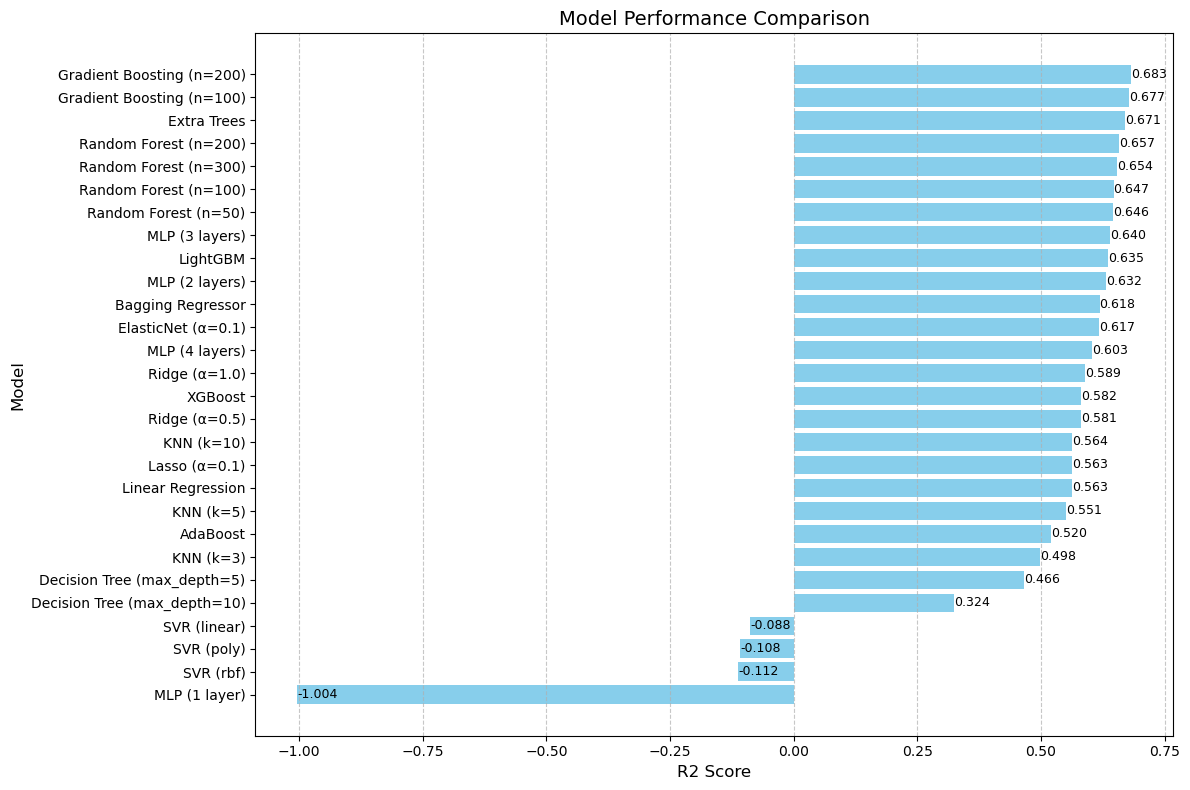

In [ ]:
# Delecte 'days_since_update', 'update_rate' and 'has_description', 'is_template'
df = pd.read_csv('github_repo_features_new.csv', parse_dates=["created_at", "updated_at", "pushed_at"])
results_df_cv, best_pipeline, test_r2_best = train_and_evaluate_models_cv(df, save_path="best_model_cv.pkl", exclude_features=['days_since_update', 'update_rate', 'has_description', 'is_template'])
visualize_results_cv(results_df_cv)

Linear Regression         | CV R2: 0.5631 ± 0.2288
Ridge (α=1.0)             | CV R2: 0.5885 ± 0.2073
Ridge (α=0.5)             | CV R2: 0.5809 ± 0.2147


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:639: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 22157562031.933624, tolerance: 116177047.82255821
  model = cd_fast.sparse_enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:639: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 43679582081.830444, tolerance: 131395582.11836006
  model = cd_fast.sparse_enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:639: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 9375408459.938812, tolerance: 112683003.04939249
  model = cd_fast.sparse_enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_des

Lasso (α=0.1)             | CV R2: 0.5634 ± 0.2295
ElasticNet (α=0.1)        | CV R2: 0.6169 ± 0.1730
Decision Tree (max_depth=5) | CV R2: 0.4659 ± 0.1868
Decision Tree (max_depth=10) | CV R2: 0.3238 ± 0.2072
Random Forest (n=50)      | CV R2: 0.6457 ± 0.1678
Random Forest (n=100)     | CV R2: 0.6467 ± 0.1701
Random Forest (n=200)     | CV R2: 0.6572 ± 0.1595
Random Forest (n=300)     | CV R2: 0.6538 ± 0.1620
Gradient Boosting (n=100) | CV R2: 0.6772 ± 0.1398
Gradient Boosting (n=200) | CV R2: 0.6827 ± 0.1450
AdaBoost                  | CV R2: 0.5197 ± 0.1971
Extra Trees               | CV R2: 0.6707 ± 0.1438
Bagging Regressor         | CV R2: 0.6184 ± 0.1589
SVR (linear)              | CV R2: -0.0883 ± 0.0231
SVR (rbf)                 | CV R2: -0.1119 ± 0.0259
SVR (poly)                | CV R2: -0.1080 ± 0.0270
KNN (k=3)                 | CV R2: 0.4983 ± 0.1484
KNN (k=5)                 | CV R2: 0.5506 ± 0.0977
KNN (k=10)                | CV R2: 0.5635 ± 0.1004


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_netwo

MLP (1 layer)             | CV R2: -1.0040 ± 0.4620


...

MLP (2 layers)            | CV R2: 0.6318 ± 0.1882


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_netwo

MLP (3 layers)            | CV R2: 0.6399 ± 0.1910


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_netwo

MLP (4 layers)            | CV R2: 0.6029 ± 0.2061
XGBoost                   | CV R2: 0.5818 ± 0.2079
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000150 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2279
[LightGBM] [Info] Number of data points in the train set: 640, number of used features: 26
[LightGBM] [Info] Start training from score 51904.304688
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furth

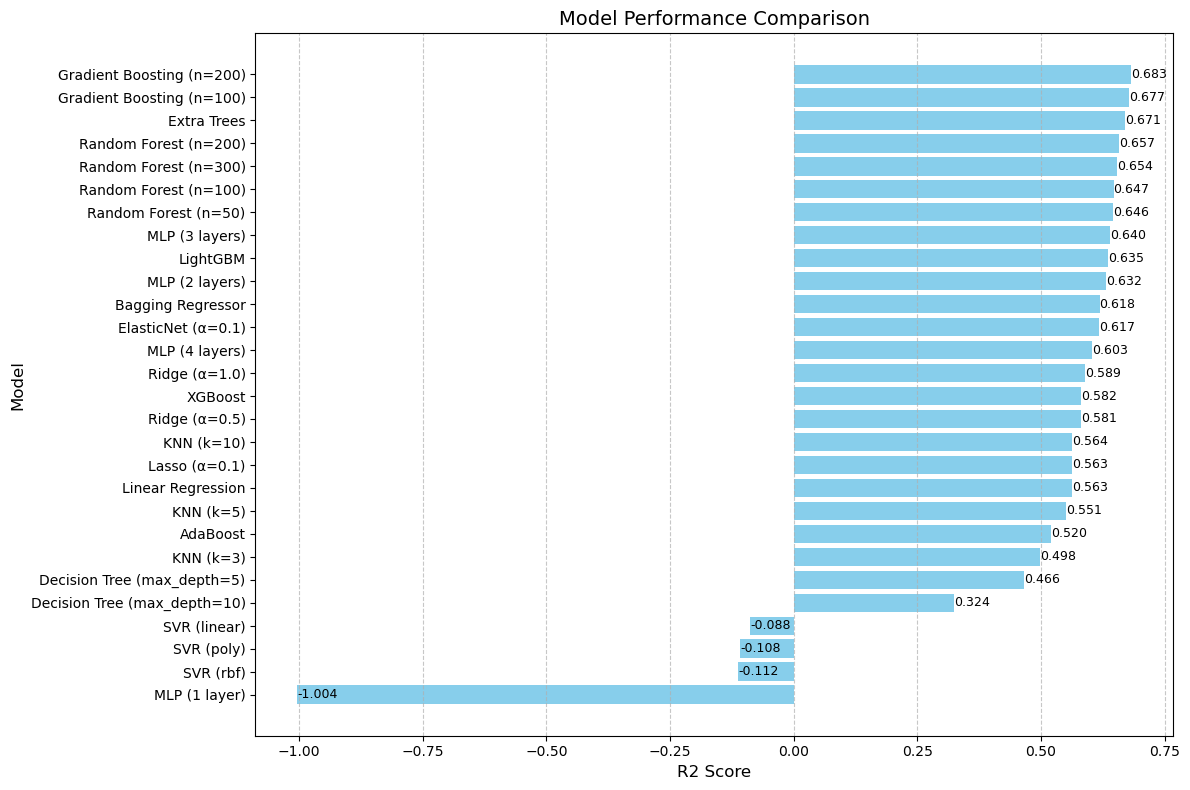

In [ ]:
# Delecte 'days_since_update', 'update_rate' and 'has_description', 'is_template', 'has_downloads'
df = pd.read_csv('github_repo_features_new.csv', parse_dates=["created_at", "updated_at", "pushed_at"])
results_df_cv, best_pipeline, test_r2_best = train_and_evaluate_models_cv(df, save_path="best_model_cv.pkl", exclude_features=['days_since_update', 'update_rate', 'has_description', 'is_template', 'has_downloads'])
visualize_results_cv(results_df_cv)

Linear Regression         | CV R2: 0.5631 ± 0.2288
Ridge (α=1.0)             | CV R2: 0.5885 ± 0.2073
Ridge (α=0.5)             | CV R2: 0.5809 ± 0.2147


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:639: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 22157562031.933624, tolerance: 116177047.82255821
  model = cd_fast.sparse_enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:639: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 43679582081.830444, tolerance: 131395582.11836006
  model = cd_fast.sparse_enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:639: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 9375408459.938812, tolerance: 112683003.04939249
  model = cd_fast.sparse_enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_des

Lasso (α=0.1)             | CV R2: 0.5634 ± 0.2295
ElasticNet (α=0.1)        | CV R2: 0.6169 ± 0.1730
Decision Tree (max_depth=5) | CV R2: 0.4659 ± 0.1868
Decision Tree (max_depth=10) | CV R2: 0.3238 ± 0.2072
Random Forest (n=50)      | CV R2: 0.6457 ± 0.1678
Random Forest (n=100)     | CV R2: 0.6467 ± 0.1701
Random Forest (n=200)     | CV R2: 0.6572 ± 0.1595
Random Forest (n=300)     | CV R2: 0.6538 ± 0.1620
Gradient Boosting (n=100) | CV R2: 0.6772 ± 0.1398
Gradient Boosting (n=200) | CV R2: 0.6827 ± 0.1450
AdaBoost                  | CV R2: 0.5197 ± 0.1971
Extra Trees               | CV R2: 0.6707 ± 0.1438
Bagging Regressor         | CV R2: 0.6184 ± 0.1589
SVR (linear)              | CV R2: -0.0883 ± 0.0231
SVR (rbf)                 | CV R2: -0.1119 ± 0.0259
SVR (poly)                | CV R2: -0.1080 ± 0.0270
KNN (k=3)                 | CV R2: 0.4983 ± 0.1484
KNN (k=5)                 | CV R2: 0.5506 ± 0.0977
KNN (k=10)                | CV R2: 0.5635 ± 0.1004


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_netwo

MLP (1 layer)             | CV R2: -1.0040 ± 0.4620


...

MLP (2 layers)            | CV R2: 0.6318 ± 0.1882


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_netwo

MLP (3 layers)            | CV R2: 0.6399 ± 0.1910


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_netwo

MLP (4 layers)            | CV R2: 0.6029 ± 0.2061
XGBoost                   | CV R2: 0.5818 ± 0.2079
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000110 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2279
[LightGBM] [Info] Number of data points in the train set: 640, number of used features: 26
[LightGBM] [Info] Start training from score 51904.304688
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furth

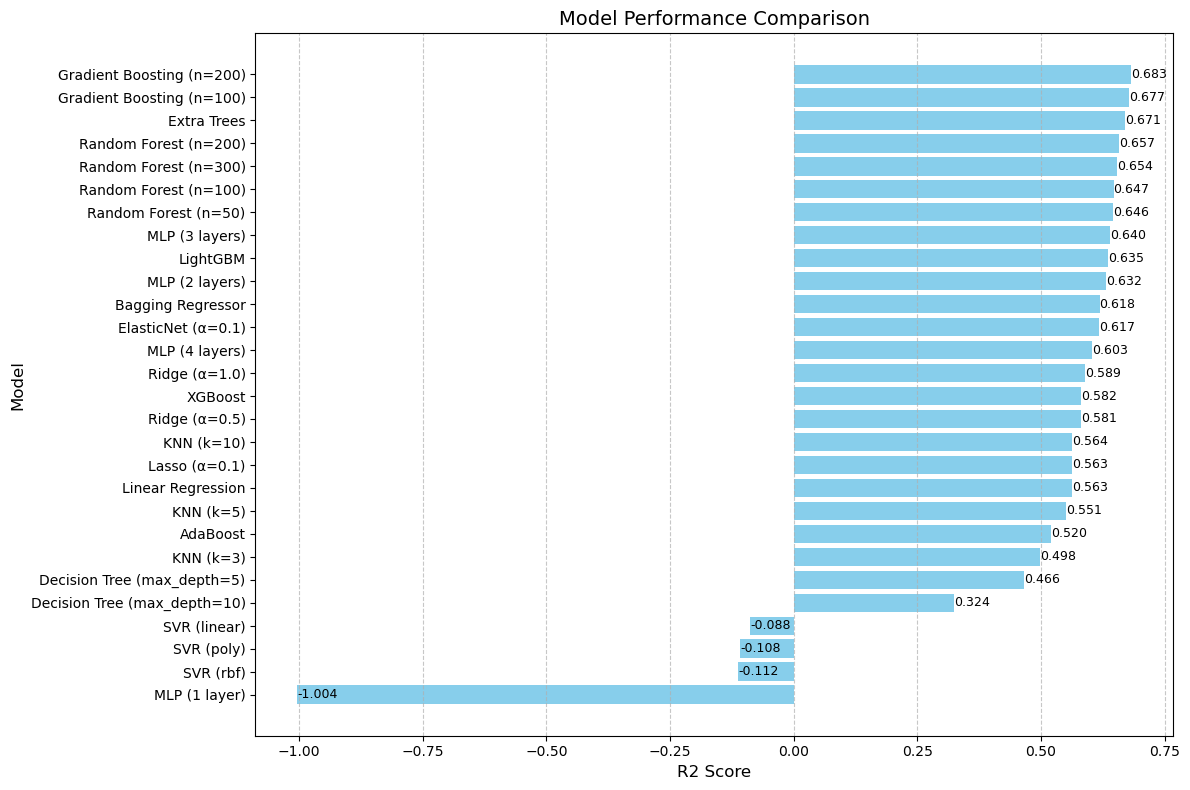

In [ ]:
# Delecte 'days_since_update', 'update_rate' and 'has_description', 'is_template', 'has_downloads', 'achived'
df = pd.read_csv('github_repo_features_new.csv', parse_dates=["created_at", "updated_at", "pushed_at"])
exclude_features = ['days_since_update', 'update_rate', 'has_description', 'is_template', 'has_downloads', 'archived']
results_df_cv, best_pipeline, test_r2_best = train_and_evaluate_models_cv(df, save_path="best_model_cv.pkl", exclude_features=exclude_features)
visualize_results_cv(results_df_cv)

Linear Regression         | CV R2: 0.5822 ± 0.1961
Ridge (α=1.0)             | CV R2: 0.6016 ± 0.1832
Ridge (α=0.5)             | CV R2: 0.5957 ± 0.1880


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:639: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 22168076848.338745, tolerance: 116177047.82255821
  model = cd_fast.sparse_enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:639: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 43679073303.4794, tolerance: 131395582.11836006
  model = cd_fast.sparse_enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:639: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 9376551044.774902, tolerance: 112683003.04939249
  model = cd_fast.sparse_enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_desce

Lasso (α=0.1)             | CV R2: 0.5824 ± 0.1968
ElasticNet (α=0.1)        | CV R2: 0.6255 ± 0.1558
Decision Tree (max_depth=5) | CV R2: 0.4372 ± 0.1717
Decision Tree (max_depth=10) | CV R2: 0.4179 ± 0.1654
Random Forest (n=50)      | CV R2: 0.6407 ± 0.1599
Random Forest (n=100)     | CV R2: 0.6472 ± 0.1562
Random Forest (n=200)     | CV R2: 0.6573 ± 0.1483
Random Forest (n=300)     | CV R2: 0.6556 ± 0.1520
Gradient Boosting (n=100) | CV R2: 0.6570 ± 0.1395
Gradient Boosting (n=200) | CV R2: 0.6586 ± 0.1541
AdaBoost                  | CV R2: 0.5496 ± 0.2043
Extra Trees               | CV R2: 0.6780 ± 0.1348
Bagging Regressor         | CV R2: 0.5849 ± 0.1793
SVR (linear)              | CV R2: -0.0883 ± 0.0231
SVR (rbf)                 | CV R2: -0.1119 ± 0.0259
SVR (poly)                | CV R2: -0.1055 ± 0.0264
KNN (k=3)                 | CV R2: 0.4956 ± 0.1440
KNN (k=5)                 | CV R2: 0.5456 ± 0.0968
KNN (k=10)                | CV R2: 0.5626 ± 0.0993


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_netwo

MLP (1 layer)             | CV R2: -1.0194 ± 0.4603


...

MLP (2 layers)            | CV R2: 0.6225 ± 0.1991


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLP (3 layers)            | CV R2: 0.6378 ± 0.1973


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_netwo

MLP (4 layers)            | CV R2: 0.6074 ± 0.2071
XGBoost                   | CV R2: 0.6075 ± 0.1786
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000123 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2066
[LightGBM] [Info] Number of data points in the train set: 640, number of used features: 25
[LightGBM] [Info] Start training from score 51904.304688
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furth

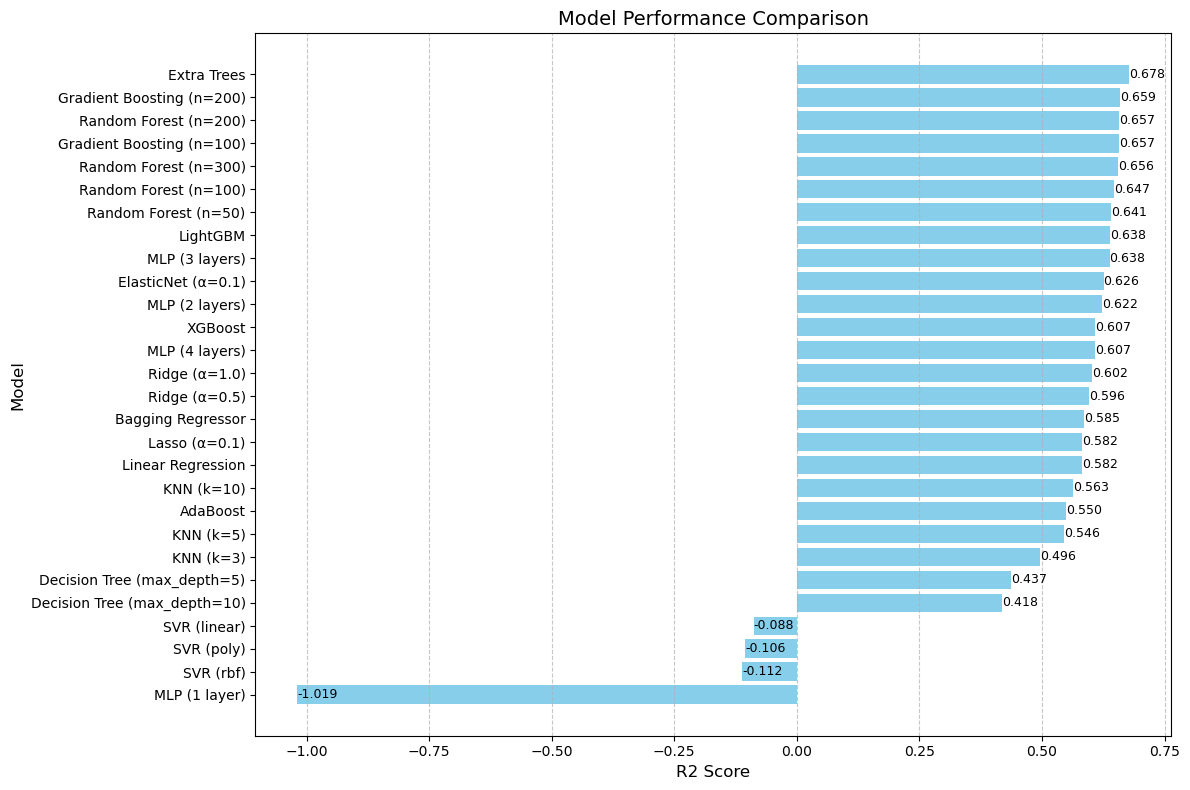

In [ ]:
# Delecte 'days_since_update', 'update_rate' and 'size'
df = pd.read_csv('github_repo_features_new.csv', parse_dates=["created_at", "updated_at", "pushed_at"])
exclude_features = ['days_since_update', 'update_rate', 'size']
results_df_cv, best_pipeline, test_r2_best = train_and_evaluate_models_cv(df, save_path="best_model_cv.pkl", exclude_features=exclude_features)
visualize_results_cv(results_df_cv)